### Simulação de Efeitos de Tratamento heterogêneos

In [111]:
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from libpysal.weights import lag_spatial
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from pyfixest.estimation import feols
import pyfixest as pf
from pyfixest.report.utils import rename_event_study_coefs

# CS ML
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

### Montando a simulação

A variável de interesse $ Y_{it} $ é gerada a partir da seguinte equação estrutural, incorporando efeitos fixos, variáveis observáveis, tratamento direto e spillover espacial:

$$
Y_{it} = \alpha + \lambda_t + \alpha_i + \beta \cdot \text{TE}_{it} + \gamma \cdot \text{Spill}_{it} + \delta_1 X_{1it} + \delta_2 X_{2it} + \delta_3 X_{3it} + \varepsilon_{it}
$$

Onde:

- $ \alpha $: intercepto constante
- $ \lambda_t = 0{,}01 \cdot (t - 2000) $: efeito fixo de tempo
- $ \alpha_i = 0{,}02 \cdot \text{cod}(i) $: efeito fixo de município
- $ \text{TE}_{it} = \min(\text{anos desde tratamento}, 3) $: efeito dinâmico truncado
- $ \text{Spill}_{it} = (W D_t)_i \cdot X\_index_{it} $: spillover espacial
- $ X_{1it}, X_{2it}, X_{3it} $: covariáveis observadas
- $ \varepsilon_{it} \sim \mathcal{N}(0, 0{,}3^2) $: erro idiossincrático

Com os coeficientes:

- $ \beta = 1{,}5 $: efeito direto do tratamento
- $ \gamma = 0{,}8 $: efeito spillover
- $ \delta_1 = 0{,}6,\ \delta_2 = 0{,}4,\ \delta_3 = 0{,}2 $

### Seleção para o Tratamento

O tratamento é atribuído com base em um escore de propensão logístico:

$$
\text{Pr}(D_i = 1) = \frac{1}{1 + \exp\left( -(\theta_1 X_{1i} + \theta_2 X_{2i} + \theta_3 X_{3i}) \right)}
$$

Com:

- $ \theta_1 = 1{,}5 $, $ \theta_2 = 1{,}0 $, $ \theta_3 = 0{,}5 $

Atribuição:

- 7% dos municípios com maior escore recebem o tratamento diretamente.
- 3% adicionais são selecionados aleatoriamente entre os demais.


In [296]:
# === Etapa 1: Carregar shapefile dos municípios do Brasil ===
shapefile_path = "C:/Users/danie/OneDrive/Data/Shape_BR_2022/BR_Municipios_2024.shp"
gdf = gpd.read_file(shapefile_path)

# Selecionar e renomear colunas principais
gdf = gdf[['CD_MUN', 'NM_MUN', 'SIGLA_UF', 'geometry']].copy()
gdf = gdf.rename(columns={'CD_MUN': 'codmun', 'NM_MUN': 'municipio', 'SIGLA_UF': 'uf'})

# Calcular centroides
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

# Mapeamento de UFs para regiões
regiao_dict = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Adiciona a coluna de região
gdf['regiao'] = gdf['uf'].map(regiao_dict)


# === Etapa 2: Simular covariáveis iniciais e suas tendências ===
np.random.seed(42)
n_mun = gdf.shape[0]
gdf['X1'] = np.random.normal(0, 1, n_mun)
gdf['X2'] = np.random.normal(0, 1, n_mun)
gdf['X3'] = np.random.normal(0, 1, n_mun)

# Aumentar os valores das variáveis X em 20% para Sul e Sudeste
regioes_ricas = ['Sul', 'Sudeste']
mask_ricas = gdf['regiao'].isin(regioes_ricas)
gdf.loc[mask_ricas, ['X1', 'X2', 'X3']] *= 1.2

# Tendência de crescimento heterogênea
gdf['X1_trend'] = np.random.normal(0.01, 0.005, n_mun)
gdf['X2_trend'] = np.random.normal(0.02, 0.007, n_mun)
gdf['X3_trend'] = np.random.normal(0.015, 0.004, n_mun)


# === Etapa 3: Expandir painel 2000–2024 com evolução dos X ===
years = list(range(2000, 2025))
panel = pd.DataFrame(
    [(row.codmun, row.municipio, row.uf,
      row.X1 + (year - 2000) * row.X1_trend,
      row.X2 + (year - 2000) * row.X2_trend,
      row.X3 + (year - 2000) * row.X3_trend,
      row.lat, row.lon, year)
     for idx, row in gdf.iterrows() for year in years],
    columns=['codmun', 'municipio', 'uf', 'X1', 'X2', 'X3', 'lat', 'lon', 'year']
)


# === Etapa 4: Atribuir tratamento a 10% dos municípios (7% via características, 3% aleatório) ===
np.random.seed(42)

# Passo 1: calcular escore de propensão ao tratamento
gdf['prop_score'] = 1 / (1 + np.exp(-(1.5 * gdf['X1'] + 1.0 * gdf['X2'] + 0.5 * gdf['X3'])))

# Passo 2: ordenar por escore e selecionar top 7%
n_7 = int(0.07 * n_mun)
treated_by_score = gdf.sort_values(by='prop_score', ascending=False).head(n_7)['codmun'].tolist()

# Passo 3: selecionar 3% aleatoriamente entre os restantes
remaining = gdf[~gdf['codmun'].isin(treated_by_score)]
n_3 = int(0.03 * n_mun)
treated_random = np.random.choice(remaining['codmun'], size=n_3, replace=False).tolist()

# Passo 4: juntar tratados
treated_muns = treated_by_score + treated_random
gdf['treated'] = gdf['codmun'].isin(treated_muns).astype(int)

# Passo 5: definir anos de tratamento entre 2005 e 2020
treatment_years = {mun: np.random.randint(2005, 2021) for mun in treated_muns}
panel['treat_year'] = panel['codmun'].map(treatment_years)
panel['D'] = ((panel['treat_year'].notnull()) & (panel['year'] >= panel['treat_year'])).astype(int)

# Calcular anos desde tratamento (efeito dinâmico)
panel['years_treated'] = (panel['year'] - panel['treat_year']).clip(lower=0)
panel['years_treated'] = panel['years_treated'].where(panel['D'] == 1, 0)
panel['treatment_effect'] = panel['years_treated'].clip(upper=3)


# === Etapa 5: Matriz de vizinhança espacial ===
w = Queen.from_dataframe(gdf)
W_sparse = w.full()[0]

# === Etapa 6: Recalcular índice socioeconômico por ano (com interações complexas) ===
panel['X_index'] = 0.0
for year in years:
    df_year = panel.loc[panel['year'] == year, ['X1', 'X2', 'X3']]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_year)
    X1s, X2s, X3s = X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2]
    
    X_index_new = (
        0.5 * (X1s + X2s + X3s) +
        0.3 * (X1s * X2s) +
        0.2 * (X1s**2 * X2s * X3s)
    )
    panel.loc[panel['year'] == year, 'X_index'] = X_index_new

# === Etapa 7: Calcular variável de spillover binário ===
panel['WD'] = 0.0

for year in years:
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # respeita a ordem
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()

# Variável binária: 1 se o município tem ao menos um vizinho tratado no ano
panel['WD1'] = (panel['WD'] > 0).astype(int)

# === Etapa 7.1: Criar variável de spillover acumulado (WD_cumulativo) ===
panel['WD_cumulativo'] = 0

for cod in panel['codmun'].unique():
    df_mun = panel[panel['codmun'] == cod].sort_values("year")
    wd_vals = df_mun["WD1"].values

    # Primeiro ano com vizinho tratado
    first_year_with_wd = np.where(wd_vals > 0)[0]

    if len(first_year_with_wd) > 0:
        start = first_year_with_wd[0]
        wd_cum_vals = np.zeros_like(wd_vals)
        wd_cum_vals[start:] = 1
        panel.loc[df_mun.index, "WD_cumulativo"] = wd_cum_vals


# === Etapa 8: Gerar variável de resultado Y com spillover apenas nos vizinhos não tratados ===
np.random.seed(42)
alpha_dict = dict(zip(gdf['codmun'], np.random.normal(0, 0.2, n_mun)))
panel['alpha_i'] = panel['codmun'].map(alpha_dict)
panel['lambda_t'] = (panel['year'] - 2000) * 0.01
panel['epsilon'] = np.random.normal(0, 0.3, panel.shape[0])

# Coeficientes
beta = 1.5   # efeito direto do tratamento
gamma = 0.8  # efeito do spillover nos vizinhos não tratados

# Geração de Y
panel['Y'] = (
    2 +
    0.6 * panel['X1'] +
    0.4 * panel['X2'] +
    0.2 * panel['X3'] +
    beta * panel['treatment_effect'] +
    gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
    panel['alpha_i'] +
    panel['lambda_t'] +
    panel['epsilon']
)


Visualizando o mapa do Brasil com os municípios que foram tratados e não tratados.

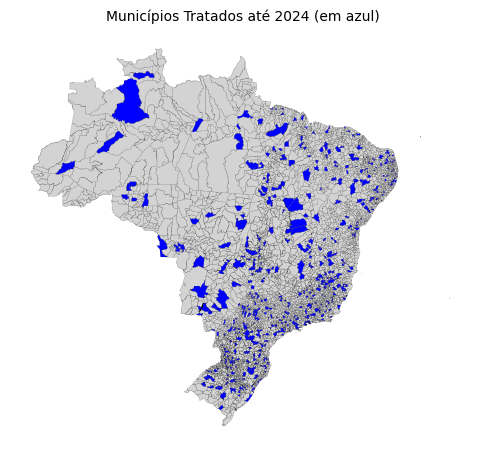

In [297]:
# Filtra apenas o último ano (2024)
panel_2024 = panel[panel['year'] == 2024]

# Junta com o GeoDataFrame para obter as geometrias
mapa_2024 = gdf.merge(panel_2024[['codmun', 'D']], on='codmun', how='left')

# Plota o mapa: municípios tratados (D=1) em azul, os demais em cinza claro
fig, ax = plt.subplots(figsize=(6, 7))
mapa_2024[mapa_2024['D'] == 0].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
mapa_2024[mapa_2024['D'] == 1].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados até 2024 (em azul)', fontsize=10)
ax.axis('off')
plt.show()

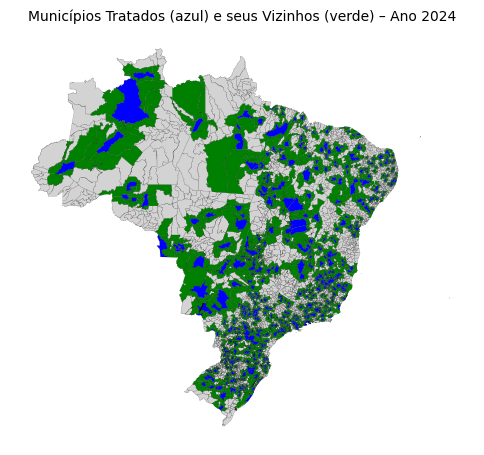

In [298]:
# 1. Filtra ano de 2024
panel_2024 = panel[panel['year'] == 2024]

# 2. Municípios tratados até 2024
treated_muns = set(panel_2024.loc[panel_2024['D'] == 1, 'codmun'])

# 3. Identifica vizinhos dos tratados
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# Coleta todos os vizinhos dos tratados
vizinhos = set()
for mun in treated_muns:
    idx = codmun_to_index.get(mun)
    if idx is not None:
        vizinhos.update([index_to_codmun[i] for i in neighbors_dict.get(idx, [])])

# Remove os próprios tratados da lista de vizinhos
vizinhos = vizinhos - treated_muns

# 4. Classificação para visualização
gdf['status'] = 'Não tratado'
gdf.loc[gdf['codmun'].isin(vizinhos), 'status'] = 'Vizinho tratado'
gdf.loc[gdf['codmun'].isin(treated_muns), 'status'] = 'Tratado'

# 5. Mapa com 3 cores
fig, ax = plt.subplots(figsize=(6, 7))
gdf[gdf['status'] == 'Não tratado'].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Vizinho tratado'].plot(ax=ax, color='green', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Tratado'].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados (azul) e seus Vizinhos (verde) – Ano 2024', fontsize=10)
ax.axis('off')
plt.show()


Filtragem adicional da base

* vizinho de tratado
* ano que esse vizinho foi "tratado"
* grupo de tratados
* grupo de vizinhos tratados
* nunca tratados


Adiciona o uma variável de efeito espacial do tratamento (1 para os vizinhos dos municípios tratados, 0 caso contrário).

In [142]:
# Inicializa a coluna WD no panel
panel['WD'] = 0.0

# Calcula WD ano a ano (importante manter a ordem correta dos municípios)
for year in years:
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # respeita a ordem do gdf
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()

panel['WD1'] = (panel['WD'] > 0).astype(int)

In [300]:
# 1. Obter os municípios tratados (independente do ano)
treated_codmuns = gdf[gdf['treated'] == 1]['codmun'].tolist()

# 2. Construir o dicionário de vizinhos (índice → codmun)
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# 3. Coletar todos os vizinhos dos tratados
vizinhos_tratados = set()
for mun in treated_codmuns:
    idx = codmun_to_index.get(mun)
    vizinhos_idx = neighbors_dict.get(idx, [])
    vizinhos_cod = [index_to_codmun[i] for i in vizinhos_idx]
    vizinhos_tratados.update(vizinhos_cod)

# 4. Remover os próprios tratados (só queremos vizinhos puros)
vizinhos_tratados -= set(treated_codmuns)

# 5. Criar a variável indicadora no painel
panel['is_neighbor_of_treated'] = panel['codmun'].isin(vizinhos_tratados).astype(int)

In [301]:
# 1. Dicionário com o ano de tratamento de cada município
treat_year_dict = panel[['codmun', 'treat_year']].dropna().drop_duplicates().set_index('codmun')['treat_year'].to_dict()

# 2. Dicionário de vizinhos: codmun → lista de codmuns vizinhos
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}
codmun_neighbors = {
    codmun: [index_to_codmun[i] for i in neighbors_dict.get(codmun_to_index[codmun], [])]
    for codmun in gdf['codmun']
}

# 3. Função para obter o menor ano de tratamento entre os vizinhos
def get_earliest_neighbor_treat_year(codmun, year):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict and treat_year_dict[v] <= year]
    return min(anos_tratamento) if anos_tratamento else None

# 4. Criar a nova variável no panel
panel['g_neighbor_of_treated_a'] = panel.apply(
    lambda row: get_earliest_neighbor_treat_year(row['codmun'], row['year']),
    axis=1
)

In [302]:
# Versão ESTÁTICA: menor ano de tratamento dos vizinhos, mesmo que ainda não tenha ocorrido
def get_min_neighbor_treat_year(codmun):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict]
    return min(anos_tratamento) if anos_tratamento else None

# Criar coluna fixa no gdf
gdf['g_neighbor_of_treated'] = gdf['codmun'].apply(get_min_neighbor_treat_year)

# Juntar com panel
panel = panel.merge(gdf[['codmun', 'g_neighbor_of_treated']], on='codmun', how='left')

In [303]:
# Criar coluna 'treated' para indicar se o município foi tratado (1) ou não (0), se treat_year > 0
panel['treated'] = (panel['treat_year'] > 0).astype(int)
# Criar coluna 'neighbor_of_treated' para indicar se o município foi tratado (1) ou não (0), se g_neighbor_of_treated > 0
panel['neighbor_of_treated'] = (panel['g_neighbor_of_treated'] > 0).astype(int)
# nunca tratados: aqueles que não foram tratados nem são vizinhos de tratados
panel['never_treated'] = ((panel['treated'] == 0) & (panel['neighbor_of_treated'] == 0)).astype(int)

In [304]:
panel['g_treated'] = panel['treat_year'].where(panel['treated'] == 1, np.nan)
panel['g_neighbor'] = panel['g_neighbor_of_treated'].where(panel['neighbor_of_treated'] == 1, np.nan)

In [305]:
# 1. Painel para efeitos diretos (tratados vs never treated limpos)
panel_de = panel[
    (panel['treated'] == 1) |  # tratados diretos
    ((panel['never_treated'] == 1) & (panel['WD_cumulativo'] == 0))  # nunca tratados limpos (sem spillover)
].copy()

# 2. Painel para efeitos indiretos (vizinhos dos tratados vs never treated limpos)
panel_id = panel[
    ((panel['neighbor_of_treated'] == 1) & (panel['treated'] == 0)) |  # vizinhos não tratados diretamente
    ((panel['never_treated'] == 1) & (panel['WD_cumulativo'] == 0))    # nunca tratados limpos (sem spillover)
].copy()


### Verificando modelos em busca do efeito do tratamento

In [306]:
# Regressão linear simples: Y ~ D
df_reg = panel.copy()

X = sm.add_constant(df_reg['D'])  # adiciona intercepto
y = df_reg['Y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                 1.317e+05
Date:                sex, 18 jul 2025   Prob (F-statistic):               0.00
Time:                        21:15:25   Log-Likelihood:            -2.1377e+05
No. Observations:              139325   AIC:                         4.275e+05
Df Residuals:                  139323   BIC:                         4.276e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4326      0.003    789.212      0.0

In [307]:
X = sm.add_constant(df_reg[['D', 'X1', 'X2', 'X3']])  # adiciona intercepto
y = df_reg['Y']

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                 2.346e+05
Date:                sex, 18 jul 2025   Prob (F-statistic):               0.00
Time:                        21:15:31   Log-Likelihood:            -1.1762e+05
No. Observations:              139325   AIC:                         2.353e+05
Df Residuals:                  139320   BIC:                         2.353e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2708      0.002   1430.703      0.0

#### TWFE

In [308]:
twfe_model = feols("Y ~ D | year + codmun", data=panel)
print(twfe_model.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.268 |        0.164 |    19.987 |      0.000 |  2.931 |   3.606 |
---
RMSE: 0.468 R2: 0.911 R2 Within: 0.495 
None


In [309]:
twfe_model2 = feols("Y ~ D + X1 + X2 + X3| year + codmun", data=panel)
print(twfe_model2.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.270 |        0.164 |    19.972 |      0.000 |  2.932 |   3.608 |
| X1            |      0.626 |        0.022 |    29.109 |      0.000 |  0.582 |   0.670 |
| X2            |      0.439 |        0.015 |    29.088 |      0.000 |  0.408 |   0.470 |
| X3            |      0.148 |        0.031 |     4.729 |      0.000 |  0.083 |   0.213 |
---
RMSE: 0.467 R2: 0.911 R2 Within: 0.497 
None


### Diferença em Diferença Espacial (Spatial DiD) conforme Delgado e Florax (2015)

O modelo clássico a ser estimado é:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \epsilon_{it} $$

Ou seja, precisamos:

- Y: resultado
- D: variável de tratamento
- WD: spillover espacial, que precisa ser calculado com base na vizinhança espacial (matriz W) e a variável D
- Efeitos fixos: município (codmun) e tempo (year)


In [310]:
# Converte para categoria para gerar dummies automaticamente
panel['codmun'] = panel['codmun'].astype('category')
panel['year'] = panel['year'].astype('category')

In [311]:
Delgado_DiD_1a = feols("Y ~ D + WD_cumulativo | year + codmun", data=panel)
print(Delgado_DiD_1a.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.228 |        0.162 |    19.947 |      0.000 |  2.894 |   3.562 |
| WD_cumulativo |      0.747 |        0.006 |   126.956 |      0.000 |  0.735 |   0.759 |
---
RMSE: 0.425 R2: 0.926 R2 Within: 0.583 
None


In [312]:
Delgado_DiD_2a = feols("Y ~ D + WD_cumulativo | year + codmun", data=panel)
print(Delgado_DiD_2a.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.228 |        0.162 |    19.947 |      0.000 |  2.894 |   3.562 |
| WD_cumulativo |      0.747 |        0.006 |   126.956 |      0.000 |  0.735 |   0.759 |
---
RMSE: 0.425 R2: 0.926 R2 Within: 0.583 
None


Adicionando covariáveis:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \delta X_{it} + \epsilon_{it} $$


In [313]:
# Regressão com efeitos fixos e covariáveis: + D + WD + X1 + X2 + X3
Delgado_DiD_1 = feols("Y ~ D + + WD_cumulativo + X1 + X2 + X3| year + codmun", data=panel)
print(Delgado_DiD_1.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.230 |        0.162 |    19.931 |      0.000 |  2.895 |   3.564 |
| WD_cumulativo |      0.746 |        0.006 |   122.361 |      0.000 |  0.733 |   0.758 |
| X1            |      0.606 |        0.023 |    26.827 |      0.000 |  0.560 |   0.653 |
| X2            |      0.379 |        0.012 |    30.774 |      0.000 |  0.354 |   0.405 |
| X3            |      0.127 |        0.030 |     4.267 |      0.000 |  0.066 |   0.188 |
---
RMSE: 0.424 R2: 0.927 R2 Within: 0.585 
None


In [314]:
Delgado_DiD_2 = feols("Y ~ D + WD_cumulativo + X1 + X2 + X3| year + codmun", data=panel)
print(Delgado_DiD_2.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.230 |        0.162 |    19.931 |      0.000 |  2.895 |   3.564 |
| WD_cumulativo |      0.746 |        0.006 |   122.361 |      0.000 |  0.733 |   0.758 |
| X1            |      0.606 |        0.023 |    26.827 |      0.000 |  0.560 |   0.653 |
| X2            |      0.379 |        0.012 |    30.774 |      0.000 |  0.354 |   0.405 |
| X3            |      0.127 |        0.030 |     4.267 |      0.000 |  0.066 |   0.188 |
---
RMSE: 0.424 R2: 0.927 R2 Within: 0.585 
None


#### Gardner (2022)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Gardner (2022).

O modelo de Gardner (2022) está estimando o efeito médio do tratamento sobre os tratados (ATT), de forma agregada ou média, controlando por efeitos fixos e covariáveis (se houver), mas corrigindo um problema comum nas abordagens tradicionais baseadas em dois estágios (two-way fixed effects - TWFE): viés de composição causado por comparação entre grupos tratados em momentos diferentes.

* Ele evita o viés de comparação entre grupos tratados em momentos diferentes, porque o segundo estágio utiliza apenas a variação do tratamento ao longo do tempo, após controlar para efeitos fixos e covariáveis.
* Ao não incluir diretamente os efeitos fixos na segunda regressão, ele evita problemas de colinearidade e viés de composição que afetam o modelo TWFE tradicional.

**Primeiro Estágio: Remoção de efeitos fixos e covariáveis**

Neste passo, estima-se uma regressão linear do desfecho sobre covariáveis e efeitos fixos de unidade e tempo:
 
$$
Y_{it} = X_{it}'\beta + \gamma_i + \delta_t + \epsilon_{it}
$$
 
Onde:  
- $\gamma_i$ representa o efeito fixo da unidade,  
- $\delta_t$ representa o efeito fixo de tempo,  
- $X_{it}$ são as covariáveis.
 
Após essa regressão, obtêm-se os **resíduos ajustados**:

$$
\tilde{Y}_{it} = Y_{it} - \hat{X}_{it}'\hat{\beta} - \hat{\gamma}_i - \hat{\delta}_t
$$
 
**Segundo Estágio: Estimação do efeito do tratamento**
 
Regressa-se o resíduo $\tilde{Y}_{it}$ apenas na variável de tratamento $D_{it}$ (por exemplo, uma dummy indicando o período pós-tratamento):

$$
\tilde{Y}_{it} = \theta \cdot D_{it} + u_{it}
$$

O coeficiente $\theta$ obtido dessa regressão representa a **estimativa do efeito médio do tratamento sobre os tratados (ATT)**.

In [315]:
# Estima o modelo de Gardner (did2s) com covariáveis
fit_gardner = pf.did2s(
    data=panel,
    yname="Y",                     # variável dependente
    treatment="D",                # dummy de tratamento
    first_stage="~ X1 + X2 + X3 | codmun + year",  # controles + efeitos fixos
    second_stage="~ D",           # variável de interesse
    cluster="codmun"              # erro padrão clusterizado
)
print(fit_gardner.summary())

###

Estimation:  DID2S
Dep. var.: Y_hat, Fixed effects: 0
Inference:  CRV1 (GMM)
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.445 |        0.016 |   214.438 |      0.000 |  3.414 |   3.477 |
---
RMSE: 0.472 R2: 0.711 
None


***Gardner - Event Study***

In [260]:
panel['year'] = pd.to_numeric(panel['year'], errors='coerce').astype(float)
panel['treat_year'] = pd.to_numeric(panel['treat_year'], errors='coerce').astype(float)

# Substitui os valores ausentes de tratamento por infinito
panel['treat_year'] = panel['treat_year'].fillna(np.inf)

# Calcula o ano relativo
panel['rel_year'] = panel['year'] - panel['treat_year']

In [261]:
fit_did2s = pf.did2s(
    data=panel,
    yname="Y", 
    treatment="D",
    first_stage="~ 0 |  codmun + year",
    second_stage="~i(rel_year, ref= -1.0)",
    cluster="codmun",
)

In [176]:
figsize = [400, 200]

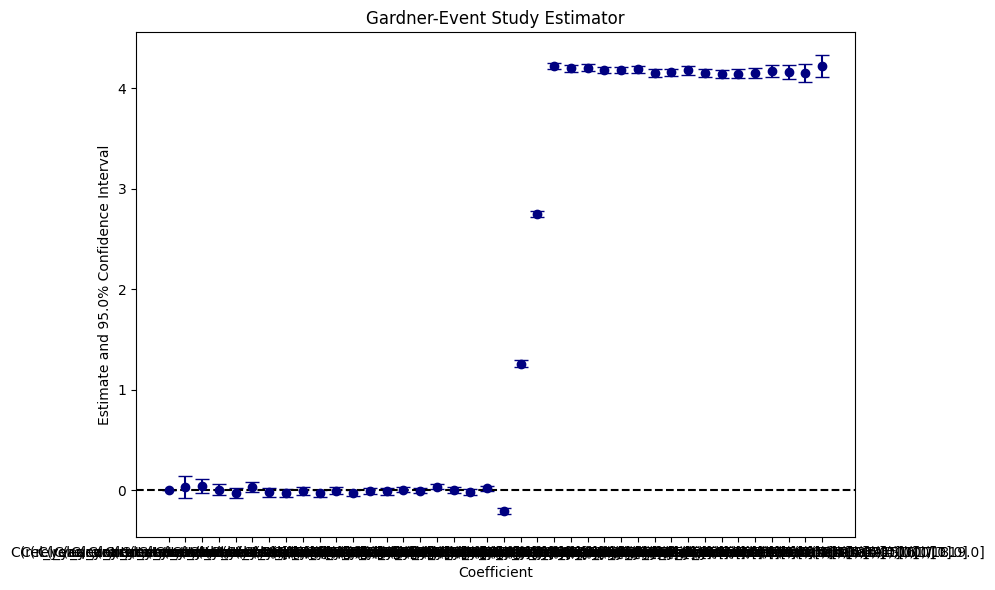

In [177]:
fit_did2s.iplot(coord_flip=False, title="Gardner-Event Study Estimator", yintercept=0)

In [178]:
fit_did2s_v2 = pf.did2s(
    data=panel,
    yname="Y", 
    treatment="D",
    first_stage="~ X1 + X2 + X3 | codmun + year",
    second_stage="~i(rel_year, ref= -1.0)",
    cluster="codmun",
)

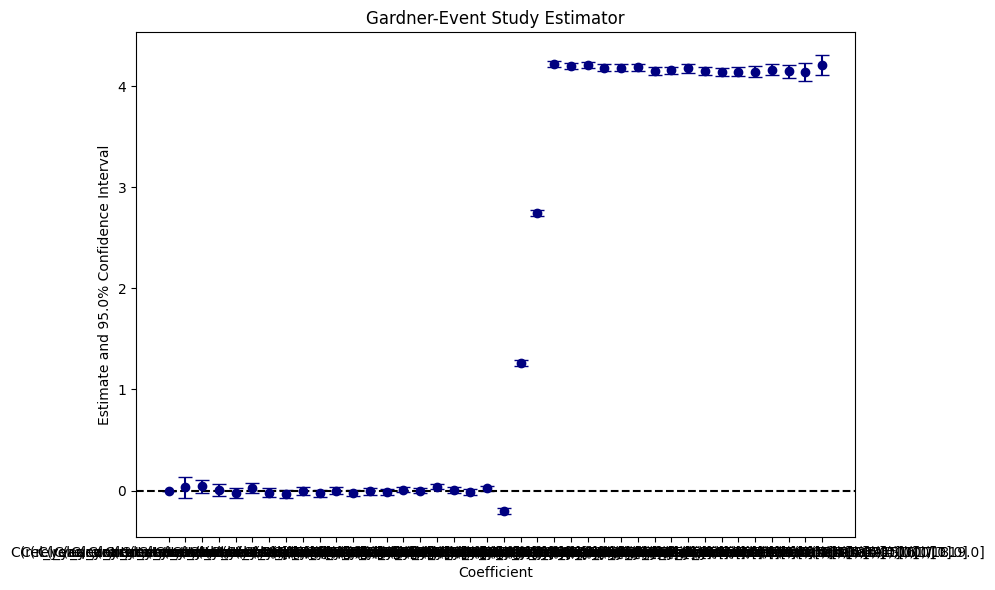

In [179]:
fit_did2s_v2.iplot(coord_flip=False, title="Gardner-Event Study Estimator", yintercept=0)

In [180]:
fit_did2s_v2.summary()

###

Estimation:  DID2S
Dep. var.: Y_hat, Fixed effects: 0
Inference:  CRV1 (GMM)
Observations:  139325

| Coefficient                                     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| C(rel_year,contr.treatment(base=-1.0))[T.-inf]  |     -0.000 |        0.000 |   -70.824 |      0.000 | -0.000 |  -0.000 |
| C(rel_year,contr.treatment(base=-1.0))[T.-20.0] |      0.032 |        0.054 |     0.591 |      0.555 | -0.074 |   0.138 |
| C(rel_year,contr.treatment(base=-1.0))[T.-19.0] |      0.041 |        0.034 |     1.205 |      0.228 | -0.026 |   0.108 |
| C(rel_year,contr.treatment(base=-1.0))[T.-18.0] |      0.007 |        0.029 |     0.242 |      0.809 | -0.050 |   0.064 |
| C(rel_year,contr.treatment(base=-1.0))[T.-17.0] |     -0.025 |        0.025 |    -1.006 |      0.314 | -0.074 |   0.024 |
| C(rel_year,contr.treatmen

### Sun & Abraham (2020)

O modelo de Sun & Abraham (2020) é uma extensão do modelo TWFE, que busca corrigir o viés de composição causado por diferenças temporais no tratamento entre grupos tratados. Ele utiliza uma abordagem de regressão em dois estágios, semelhante ao modelo de Gardner (2022), mas com foco na heterogeneidade do tratamento.




In [181]:
fit_sun_abraham = pf.event_study(
    data=panel,
    yname="Y",
    idname="codmun",
    tname="year",
    gname="treat_year",     # coluna que indica o ano de tratamento de cada unidade
    estimator="saturated",  # Modelo de Sun & Abraham
    cluster="codmun",
    att=True
)

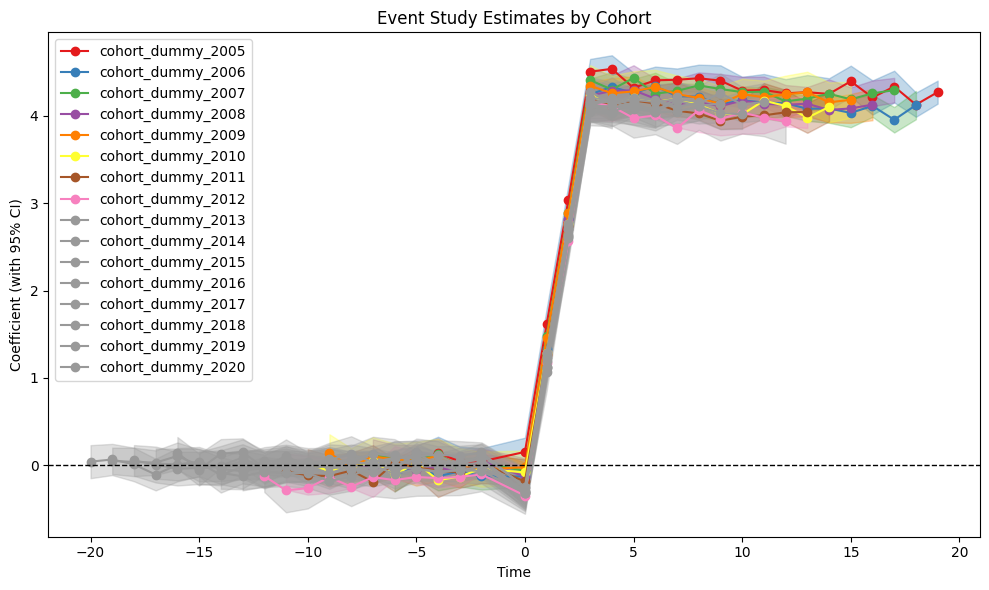

In [182]:
fit_sun_abraham.iplot()

In [183]:
fit_sun_abraham.tidy()

,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%
Coefficient,,,,,,
"C(rel_time,contr.treatment(base=-1.0))[T.-5.0]:cohort_dummy_2005",0.036414,0.093968,0.387513,0.698392,-0.147800,0.220628
"C(rel_time,contr.treatment(base=-1.0))[T.-4.0]:cohort_dummy_2005",0.138262,0.096054,1.439423,0.150087,-0.050041,0.326566
"C(rel_time,contr.treatment(base=-1.0))[T.-3.0]:cohort_dummy_2005",0.044478,0.086173,0.516147,0.605772,-0.124454,0.213410
"C(rel_time,contr.treatment(base=-1.0))[T.-2.0]:cohort_dummy_2005",0.043170,0.077653,0.555936,0.578277,-0.109060,0.195400
"C(rel_time,contr.treatment(base=-1.0))[T.0.0]:cohort_dummy_2005",0.152669,0.083089,1.837418,0.066201,-0.010218,0.315555
...,...,...,...,...,...,...
"C(rel_time,contr.treatment(base=-1.0))[T.0.0]:cohort_dummy_2020",-0.319889,0.096358,-3.319809,0.000907,-0.508787,-0.130990
"C(rel_time,contr.treatment(base=-1.0))[T.1.0]:cohort_dummy_2020",1.121672,0.089086,12.590825,0.000000,0.947028,1.296316
"C(rel_time,contr.treatment(base=-1.0))[T.2.0]:cohort_dummy_2020",2.607767,0.097057,26.868350,0.000000,2.417497,2.798037


#### Callaway & Sant'Anna (2021)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Callaway e Sant'Anna (2021). Desconsiderando o efeito espacial.


Precisamos ajustar a base para que o estimador funcione corretamente.

In [55]:
panel.loc[panel['g_treated'] == 0, 'g_treated'] = np.inf
panel['g_treated'] = panel['g_treated'].astype(float)
panel['year'] = panel['year'].astype(int)
panel['g_treated'] = panel['g_treated'].fillna(np.inf)
panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

Identificando a base de dados para utilizar com o modelo de ML.

In [56]:
dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['g_treated']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139325 entries, 0 to 139324
Columns: 28 entries, codmun to g_neighbor
dtypes: float64(19), int64(6), object(3)
memory usage: 29.8+ MB



Rodando o modelo com:
* ml_g=DummyRegressor(),
* ml_m=DummyClassifier(),


In [57]:
dml_obj = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)
dml_obj.fit()
print(dml_obj.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.1019   0.0970   1.0500  0.2937 -0.0883  0.2921
ATT(2005.0,2001,2002) -0.0938   0.0912  -1.0281  0.3039 -0.2727  0.0850
ATT(2005.0,2002,2003) -0.0011   0.0998  -0.0113  0.9910 -0.1968  0.1946
ATT(2005.0,2003,2004) -0.0433   0.0775  -0.5585  0.5765 -0.1951  0.1086
ATT(2005.0,2004,2005)  0.2404   0.1147   2.0966  0.0360  0.0157  0.4652
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.1012   0.0840   1.2045  0.2284 -0.0635  0.2660
ATT(2020.0,2019,2021)  1.5426   0.0815  18.9285  0.0000  1.3828  1.7023
ATT(2020.0,2019,2022)  3.0283   0.0763  39.6719  0.0000  2.8787  3.1779
ATT(2020.0,2019,2023)  4.5399   0.0822  55.2494  0.0000  4.3789  4.7010
ATT(2020.0,2019,2024)  4.4545   0.0728  61.1609  0.0000  4.3118  4.5973

[384 rows x 6 columns]


Criando os ICs.

In [58]:
level = 0.95
ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.262098  0.465891
ATT(2005.0,2001,2002) -0.436063  0.248429
ATT(2005.0,2002,2003) -0.375615  0.373356
ATT(2005.0,2003,2004) -0.333826  0.247296
ATT(2005.0,2004,2005) -0.189675  0.670547
...                         ...       ...
ATT(2020.0,2019,2020) -0.213994  0.416457
ATT(2020.0,2019,2021)  1.236916  1.848232
ATT(2020.0,2019,2022)  2.741973  3.314567
ATT(2020.0,2019,2023)  4.231723  4.848115
ATT(2020.0,2019,2024)  4.181360  4.727702

[384 rows x 2 columns]


Plotando os resultados.

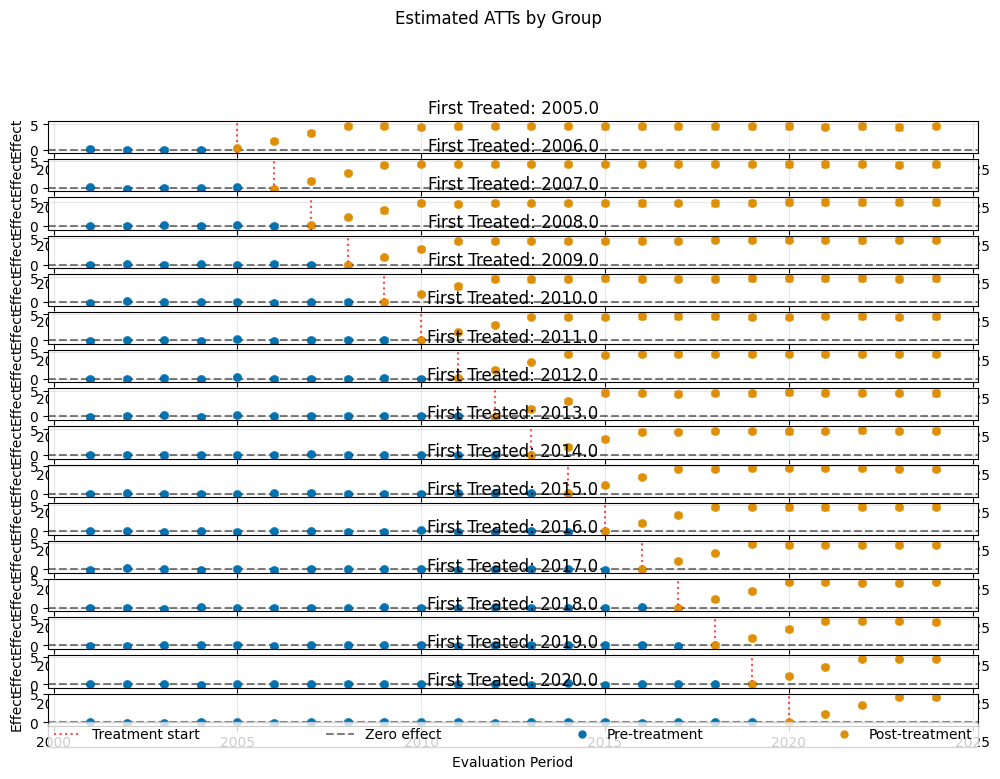

In [30]:
fig, ax = dml_obj.plot_effects()

Event Study

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err         t  P>|t|    2.5 %  97.5 %
4.216742 0.043969 95.901572    0.0 4.130563 4.30292
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.025135  0.051543    0.487654  0.625795 -0.075888  0.126158
-18.0 -0.034169  0.040933   -0.834746  0.403861 -0.114396  0.046059
-17.0 -0.057718  0.038068   -1.516155  0.129480 -0.132330  0.016895
-16.0  0.041532  0.033730    1.231301  0.218210 -0.024578  0.107641
-15.0 -0.046669  0.028442   -1.640854  0.100828 -0.102413  0.009076
-14.0 -0.008194  0.028339   -0.289154  0.772464 -0.063739  0.047350
-13.0  0.027641  0.026243    1.053271  0.292217 -0.023794  0.079076
-12.0 -0.017517  0.028161   -0.622023  0.533927 -0.072712  0.037678
-11.0  0.035401  0.025591    1.383338  0.166561 -0.014757  

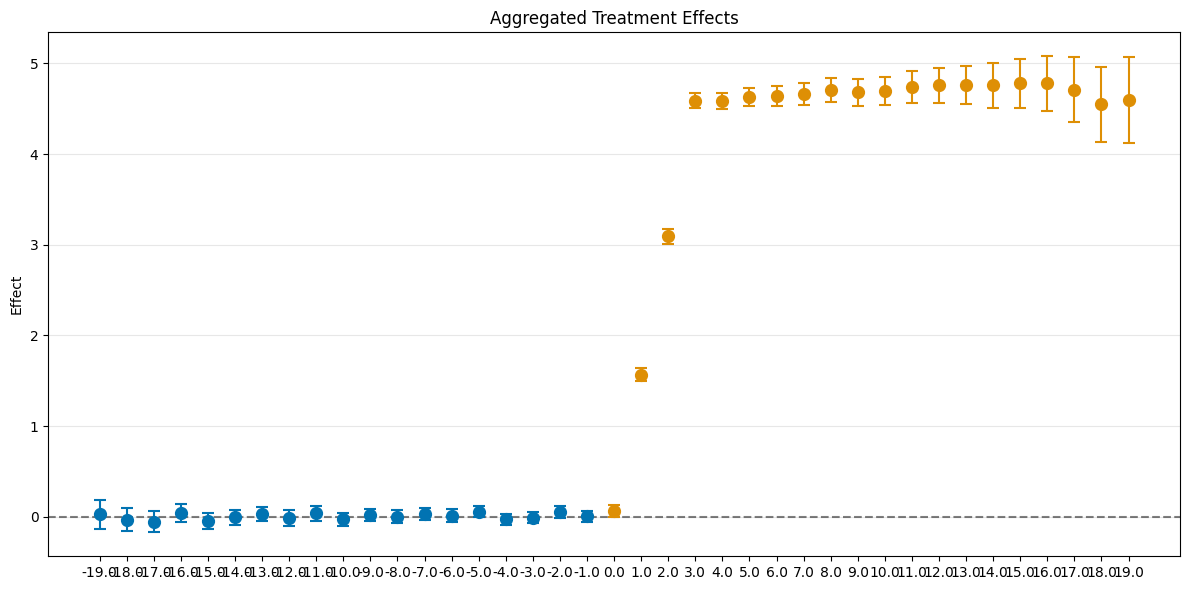

In [59]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj.bootstrap(n_rep_boot=5000)
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy)
fig, ax = aggregated_eventstudy.plot_effects()

In [64]:
print(aggregated_eventstudy.overall_summary.to_markdown())

|    |    coef |   std err |       t |   P>|t| |   2.5 % |   97.5 % |
|---:|--------:|----------:|--------:|--------:|--------:|---------:|
|  0 | 4.21674 | 0.0439695 | 95.9016 |       0 | 4.13056 |  4.30292 |


Modelo com:
* mg(.): regressão linear
* ml(.): regressão logistica

Esse se replica o modelo tradicional.

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

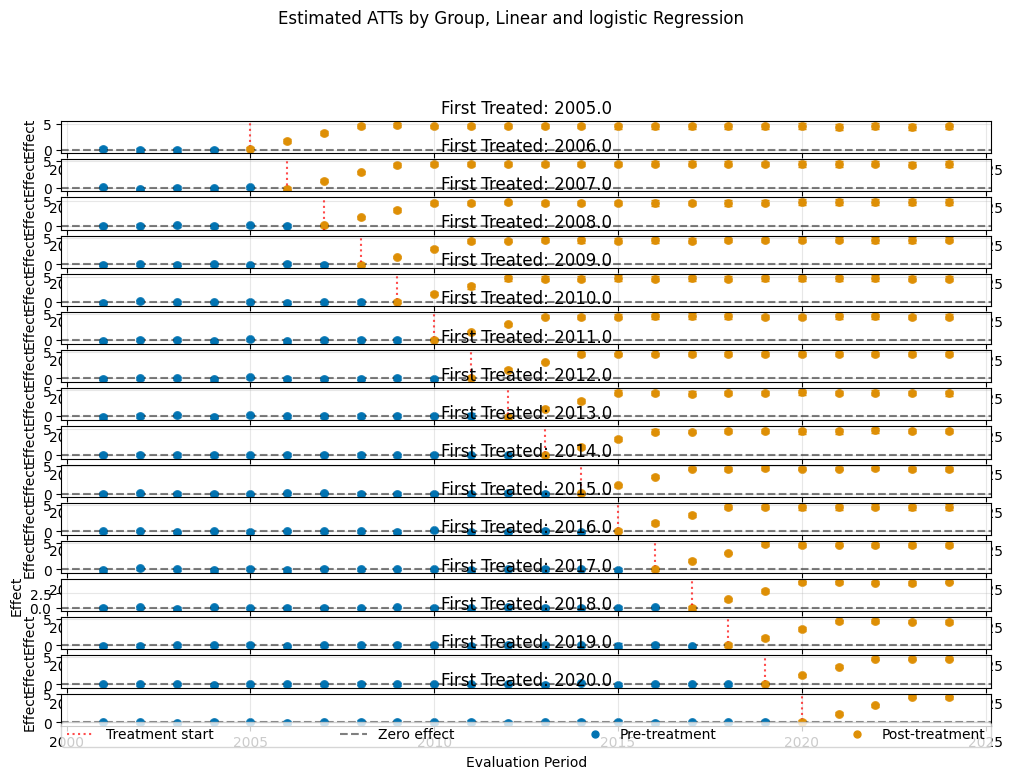

In [32]:
dml_obj_linear_logistic = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_linear_logistic.fit()
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
dml_obj_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, Linear and logistic Regression'}, ylabel='Effect'>)

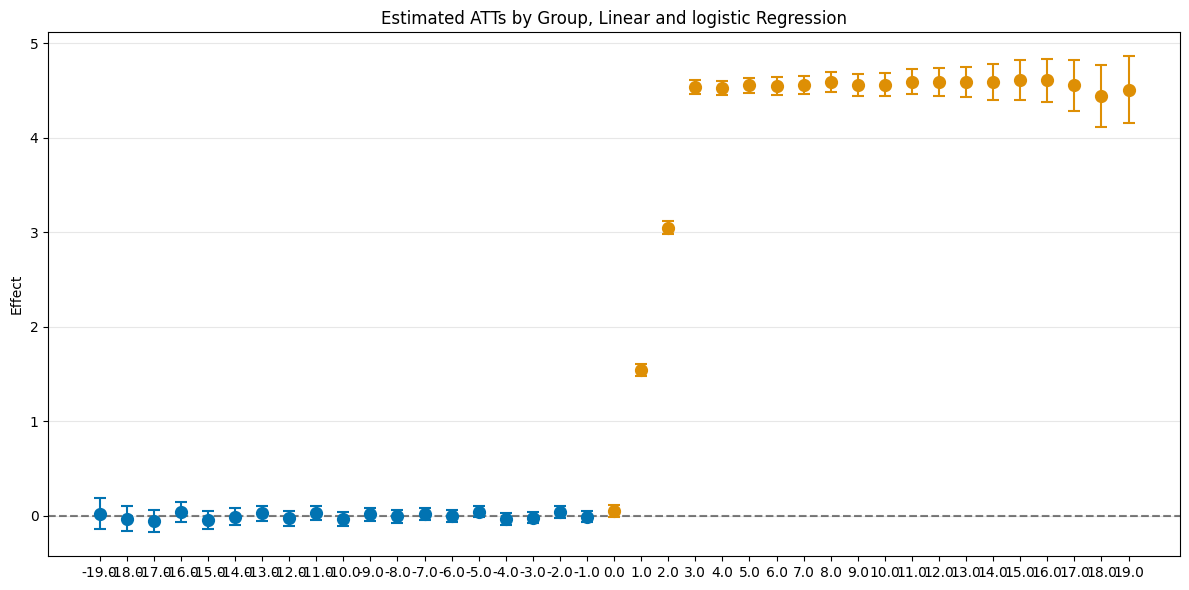

In [33]:
es_linear_logistic = dml_obj_linear_logistic.aggregate("eventstudy")
es_linear_logistic.aggregated_frameworks.bootstrap()
es_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
  coef  std err          t  P>|t|   2.5 %  97.5 %
4.1092 0.032215 127.555849    0.0 4.04606 4.17234
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.020505  0.051682    0.396757  0.691547 -0.080789  0.121799
-18.0 -0.032116  0.040992   -0.783456  0.433359 -0.112459  0.048228
-17.0 -0.056845  0.038043   -1.494237  0.135114 -0.131407  0.017717
-16.0  0.043168  0.033695    1.281147  0.200142 -0.022873  0.109209
-15.0 -0.045488  0.028563   -1.592543  0.111263 -0.101470  0.010495
-14.0 -0.011468  0.027843   -0.411868  0.680437 -0.066039  0.043104
-13.0  0.024475  0.025962    0.942740  0.345814 -0.026409  0.075360
-12.0 -0.028389  0.026212   -1.083047  0.278787 -0.079763  0.022986
-11.0  0.028982  0.024597    1.178287  0.238682 -0.019227  0.07

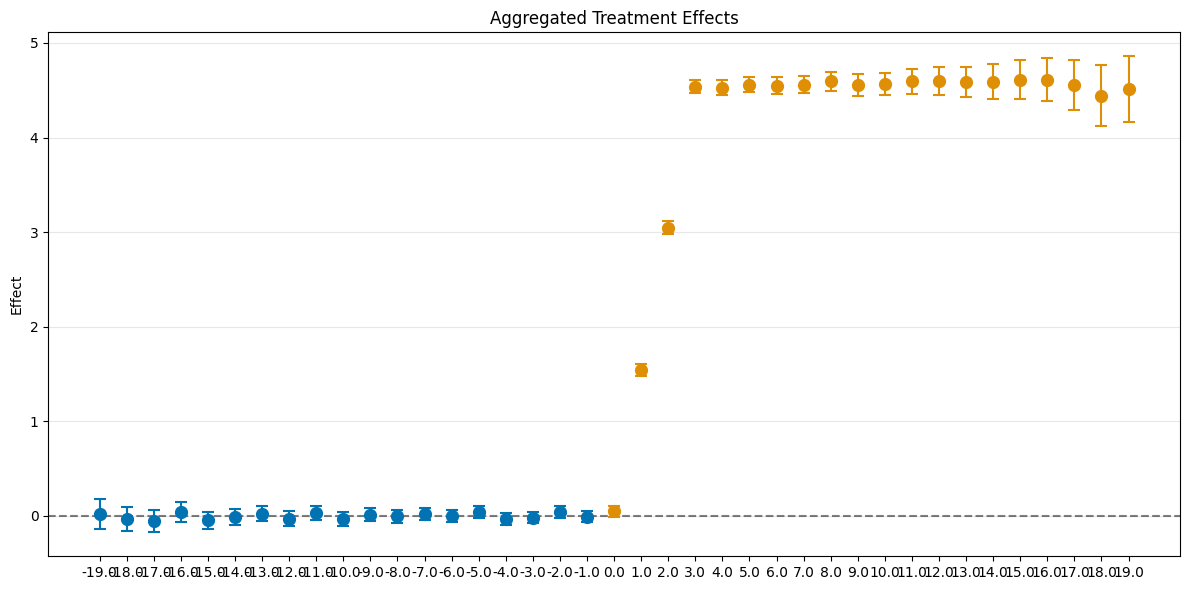

In [34]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
aggregated_eventstudy2 = dml_obj_linear_logistic.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy2.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy2)
fig, ax = aggregated_eventstudy2.plot_effects()

***Adicionando Machine Learning***

Agora vamos utilizar algorítmos tradionais de machine learning para estimar o efeito do tratamento.

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

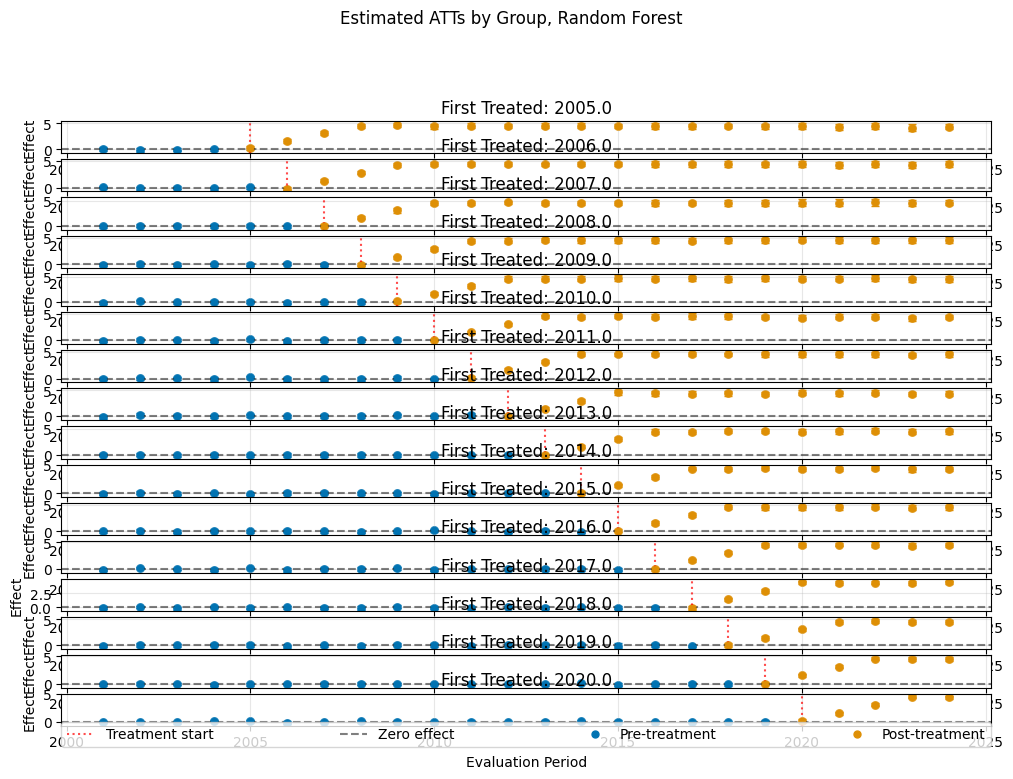

In [35]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

dml_obj_rf = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    ml_m=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    control_group="never_treated",
    n_folds=10
)

dml_obj_rf.fit()
dml_obj_rf.bootstrap(n_rep_boot=5000)
dml_obj_rf.plot_effects(title="Estimated ATTs by Group, Random Forest")

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.029524 0.033041 121.956682    0.0 3.964766 4.094282
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.007509  0.053568    0.140171  0.888525 -0.097482  0.112499
-18.0 -0.044798  0.043334   -1.033788  0.301235 -0.129730  0.040135
-17.0 -0.043891  0.040386   -1.086808  0.277122 -0.123046  0.035263
-16.0  0.044145  0.034579    1.276636  0.201731 -0.023629  0.111919
-15.0 -0.023064  0.029253   -0.788453  0.430432 -0.080399  0.034270
-14.0 -0.019935  0.028198   -0.706962  0.479590 -0.075202  0.035332
-13.0  0.023083  0.026275    0.878515  0.379665 -0.028415  0.074580
-12.0 -0.027504  0.027066   -1.016158  0.309554 -0.080552  0.025545
-11.0  0.020659  0.025840    0.799472  0.424016 -0.0299

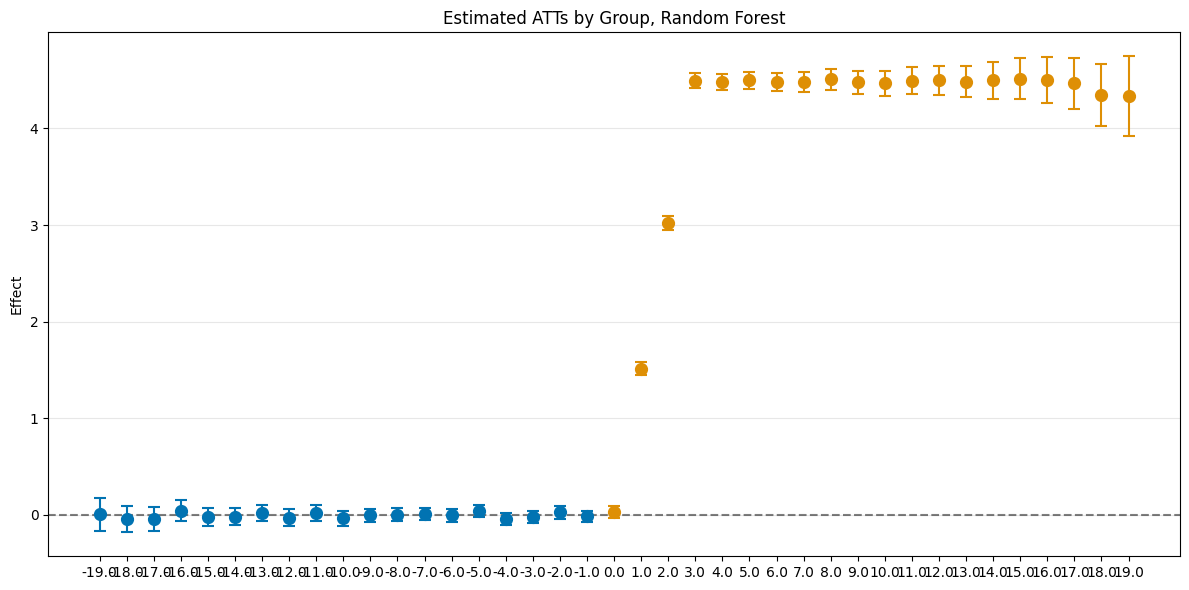

In [36]:
# 1. Agregar os efeitos como estudo de eventos (event time = t - g)
es_rf = dml_obj_rf.aggregate("eventstudy")

# 2. Rodar o bootstrap para os efeitos agregados
es_rf.aggregated_frameworks.bootstrap()

# 3. Plotar os efeitos agregados
es_rf.plot_effects(title="Estimated ATTs by Group, Random Forest")

# 4. Tabela de resultados
print(es_rf)

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.029524 0.033041 121.956682    0.0 3.964766 4.094282
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.007509  0.053568    0.140171  0.888525 -0.097482  0.112499
-18.0 -0.044798  0.043334   -1.033788  0.301235 -0.129730  0.040135
-17.0 -0.043891  0.040386   -1.086808  0.277122 -0.123046  0.035263
-16.0  0.044145  0.034579    1.276636  0.201731 -0.023629  0.111919
-15.0 -0.023064  0.029253   -0.788453  0.430432 -0.080399  0.034270
-14.0 -0.019935  0.028198   -0.706962  0.479590 -0.075202  0.035332
-13.0  0.023083  0.026275    0.878515  0.379665 -0.028415  0.074580
-12.0 -0.027504  0.027066   -1.016158  0.309554 -0.080552  0.025545
-11.0  0.020659  0.025840    0.799472  0.424016 -0.0299

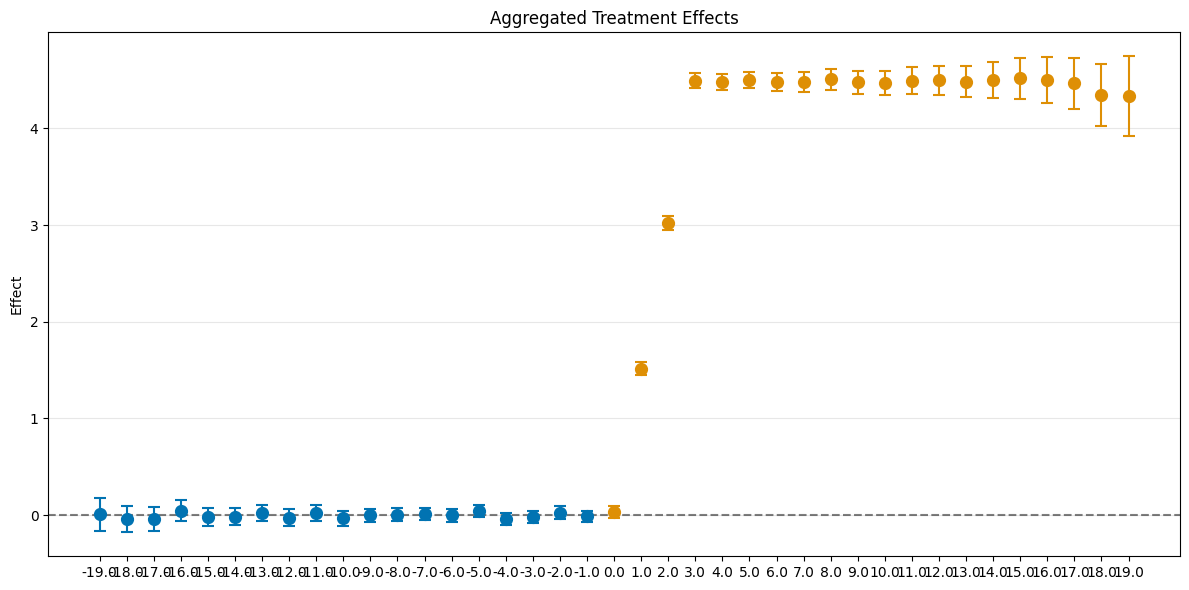

In [37]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_rf.bootstrap(n_rep_boot=5000)
aggregated_eventstudy3 = dml_obj_rf.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy3.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy3)
fig, ax = aggregated_eventstudy3.plot_effects()

### Spatially-Disentangled Doubly Robust Machine Learning for Policy Evaluation

Separando a base de dados em duas partes, uma para cada estimativa.

In [149]:
panel_de

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
25,1718451,Pugmil,TO,-0.138264,-0.979926,0.342451,-10.422515,-48.882359,2000,NaN,...,9.966838,0.0,0,NaN,NaN,0,0,1,NaN,NaN
26,1718451,Pugmil,TO,-0.132444,-0.961857,0.357684,-10.422515,-48.882359,2001,NaN,...,9.612030,0.0,0,NaN,NaN,0,0,1,NaN,NaN
27,1718451,Pugmil,TO,-0.126624,-0.943788,0.372916,-10.422515,-48.882359,2002,NaN,...,10.093803,0.0,0,NaN,NaN,0,0,1,NaN,NaN
28,1718451,Pugmil,TO,-0.120803,-0.925718,0.388149,-10.422515,-48.882359,2003,NaN,...,9.824669,0.0,0,NaN,NaN,0,0,1,NaN,NaN
29,1718451,Pugmil,TO,-0.114983,-0.907649,0.403381,-10.422515,-48.882359,2004,NaN,...,9.941119,0.0,0,NaN,NaN,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


In [150]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,NaN,...,28.078476,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,NaN,...,27.913217,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,NaN,...,28.174238,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,NaN,...,28.462075,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,NaN,...,27.960155,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


#### Direct Effect Estimation

In [289]:
panel_de.loc[panel_de['g_treated'] == 0, 'g_treated'] = np.inf
panel_de['g_treated'] = panel_de['g_treated'].astype(float)
panel_de['year'] = panel_de['year'].astype(int)
panel_de['g_treated'] = panel_de['g_treated'].fillna(np.inf)
panel_de = panel_de.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [290]:
# Direct Effect (DE) Data
dml_data_DE = DoubleMLPanelData(
    data=panel_de,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)

In [ ]:
dml_obj_DE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_DE,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_DE.fit()

In [41]:
level = 0.95
ci = dml_obj_DE.confint(level=level)
dml_obj_DE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_DE.confint(level=level, joint=True)

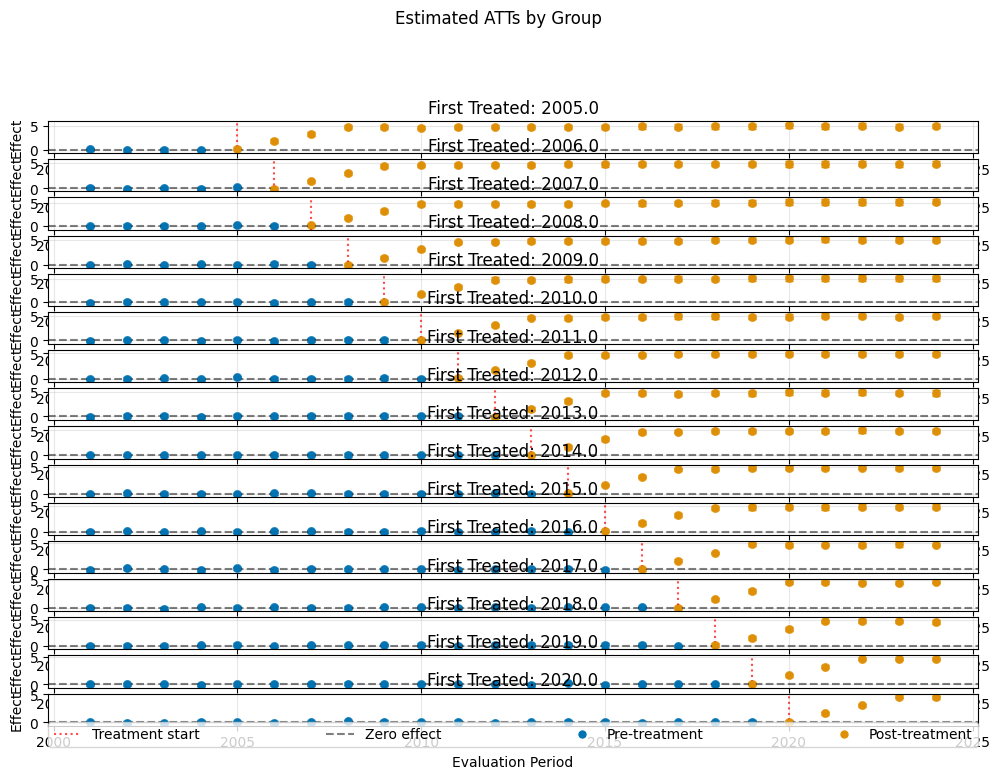

In [42]:
fig, ax = dml_obj_DE.plot_effects()

In [43]:
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
print(aggregated_eventstudy_DE)

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|   2.5 %   97.5 %
4.379467 0.031785 137.785736    0.0 4.31717 4.441763
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.023506  0.051796    0.453816  0.649962 -0.078013  0.125025
-18.0 -0.031948  0.040929   -0.780571  0.435055 -0.112167  0.048271
-17.0 -0.060654  0.038106   -1.591738  0.111444 -0.135340  0.014031
-16.0  0.040272  0.033753    1.193129  0.232819 -0.025883  0.106428
-15.0 -0.040176  0.028463   -1.411543  0.158085 -0.095962  0.015610
-14.0 -0.002685  0.027764   -0.096715  0.922952 -0.057102  0.051731
-13.0  0.038285  0.025888    1.478871  0.139175 -0.012455  0.089025
-12.0 -0.013129  0.026168   -0.501705  0.615875 -0.064418  0.038160
-11.0  0.045812  0.024528    1.867740  0.061798 -0.002262

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|   2.5 %   97.5 %
4.379467 0.031785 137.785736    0.0 4.31717 4.441763
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.023506  0.051796    0.453816  0.649962 -0.078013  0.125025
-18.0 -0.031948  0.040929   -0.780571  0.435055 -0.112167  0.048271
-17.0 -0.060654  0.038106   -1.591738  0.111444 -0.135340  0.014031
-16.0  0.040272  0.033753    1.193129  0.232819 -0.025883  0.106428
-15.0 -0.040176  0.028463   -1.411543  0.158085 -0.095962  0.015610
-14.0 -0.002685  0.027764   -0.096715  0.922952 -0.057102  0.051731
-13.0  0.038285  0.025888    1.478871  0.139175 -0.012455  0.089025
-12.0 -0.013129  0.026168   -0.501705  0.615875 -0.064418  0.038160
-11.0  0.045812  0.024528    1.867740  0.061798 -0.002262

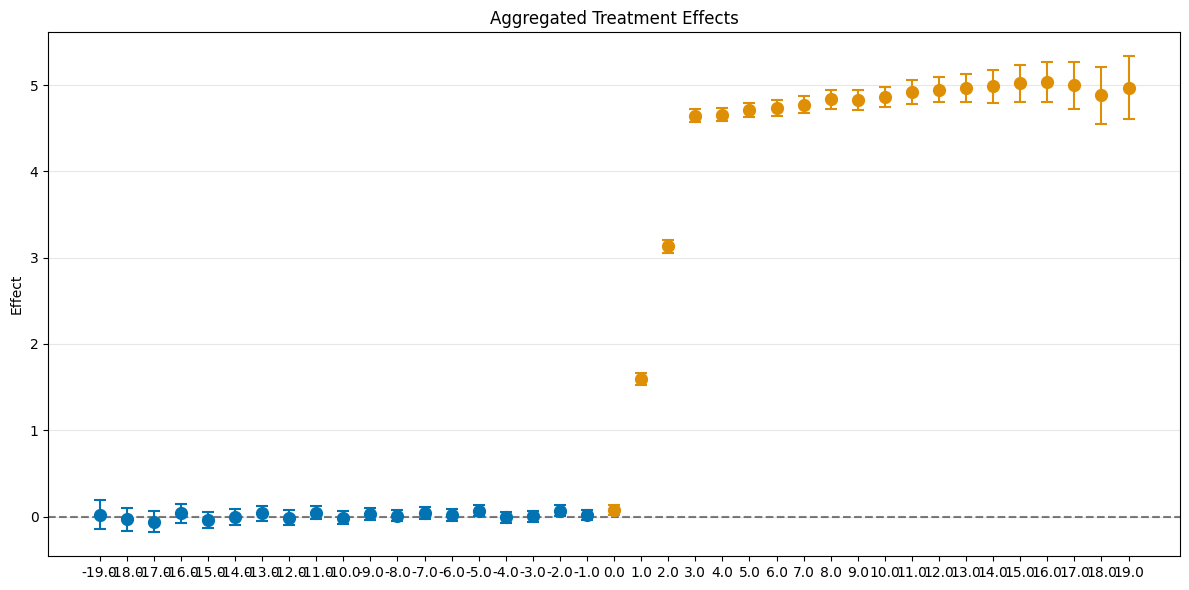

In [44]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_DE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_DE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_DE)
fig, ax = aggregated_eventstudy_DE.plot_effects()

Com ML

In [51]:
dml_obj_DE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_DE,
    ml_g=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    ml_m=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    control_group="never_treated",
    n_folds=10
)

dml_obj_DE.fit()

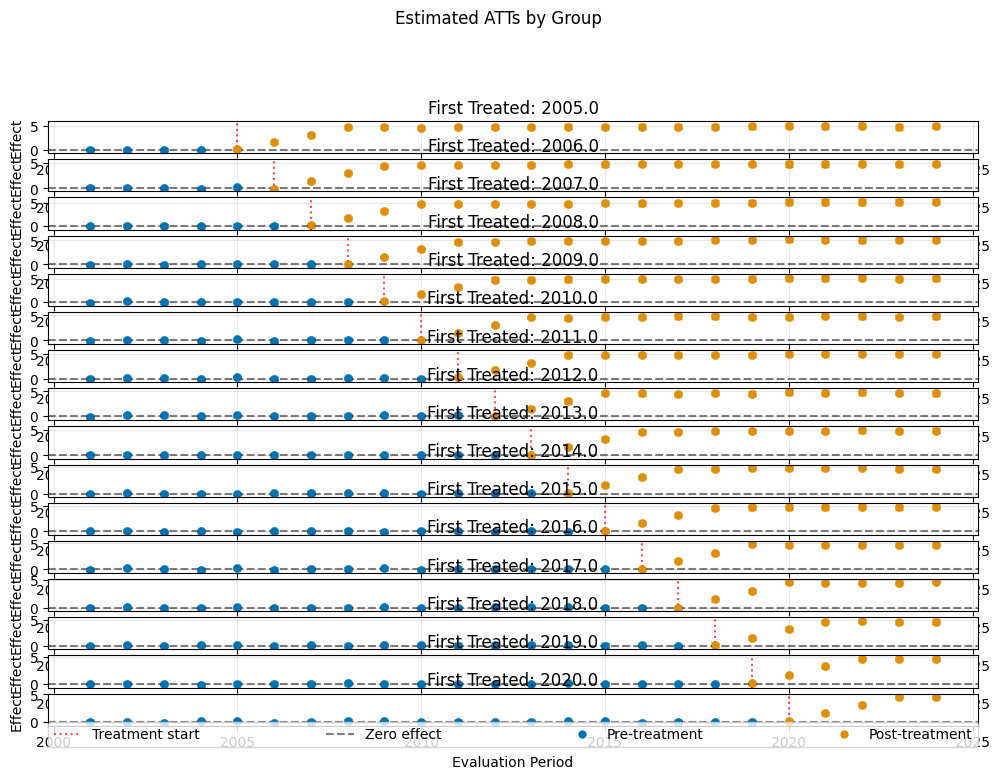

In [52]:
level = 0.95
ci = dml_obj_DE.confint(level=level)
dml_obj_DE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_DE.confint(level=level, joint=True)
fig, ax = dml_obj_DE.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.372532 0.032083 136.288959    0.0 4.309651 4.435413
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0  0.057863  0.057818    1.000790  0.316928 -0.055457  0.171184
-18.0 -0.022416  0.044121   -0.508071  0.611403 -0.108892  0.064059
-17.0 -0.051052  0.039328   -1.298107  0.194251 -0.128133  0.026030
-16.0  0.039617  0.034540    1.146999  0.251382 -0.028080  0.107314
-15.0 -0.017522  0.030513   -0.574249  0.565799 -0.077328  0.042283
-14.0 -0.000288  0.028771   -0.010018  0.992007 -0.056679  0.056102
-13.0  0.046499  0.026427    1.759505  0.078492 -0.005298  0.098296
-12.0 -0.007216  0.027299   -0.264340  0.791518 -0.060720  0.046288
-11.0  0.054265  0.025701    2.111386  0.034739  0.0038

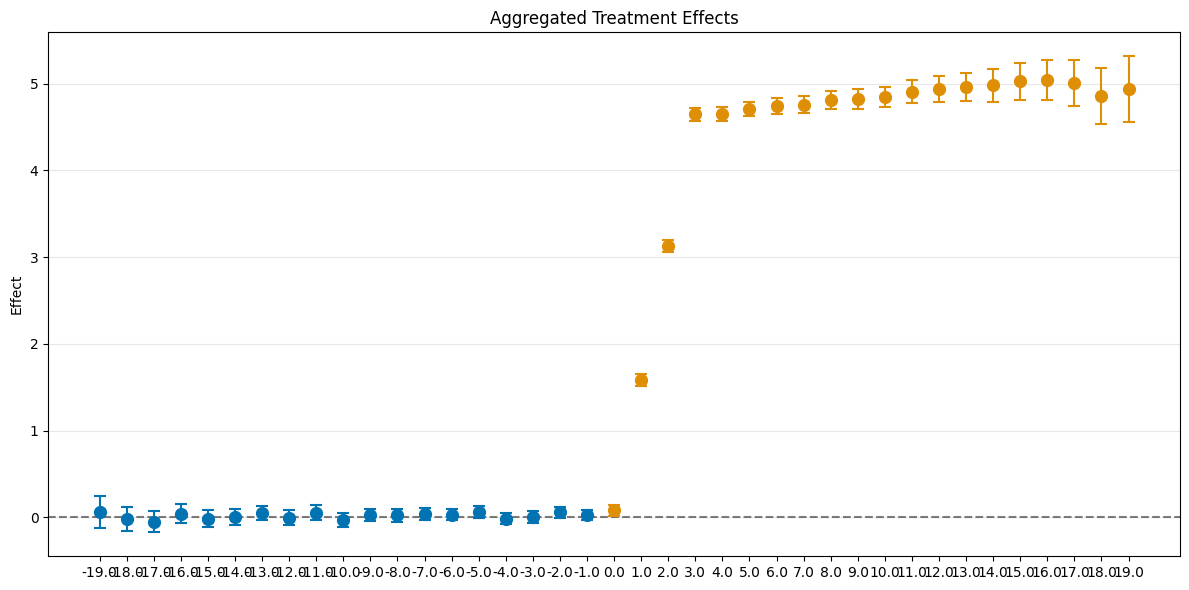

In [54]:
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_DE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_DE)
fig, ax = aggregated_eventstudy_DE.plot_effects()

#### Efeito do Tratamento Indireto

In [55]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,1100015,Alta Floresta D'Oeste,RO,0.744186,1.052547,-0.490167,-12.470132,-62.274661,2000,NaN,...,2.786034,0.0,0,NaN,NaN,0,0,1,NaN,inf
1,1100015,Alta Floresta D'Oeste,RO,0.755704,1.061911,-0.473665,-12.470132,-62.274661,2001,NaN,...,3.113227,0.0,0,NaN,NaN,0,0,1,NaN,inf
2,1100015,Alta Floresta D'Oeste,RO,0.767223,1.071276,-0.457163,-12.470132,-62.274661,2002,NaN,...,2.789141,0.0,0,NaN,NaN,0,0,1,NaN,inf
3,1100015,Alta Floresta D'Oeste,RO,0.778741,1.080640,-0.440660,-12.470132,-62.274661,2003,NaN,...,2.729967,0.0,0,NaN,NaN,0,0,1,NaN,inf
4,1100015,Alta Floresta D'Oeste,RO,0.790260,1.090004,-0.424158,-12.470132,-62.274661,2004,NaN,...,2.609857,0.0,0,NaN,NaN,0,0,1,NaN,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125395,5300108,Brasília,DF,-0.918697,0.839703,0.216768,-15.781166,-47.796851,2020,NaN,...,113.624528,0.0,0,NaN,NaN,0,0,1,NaN,inf
125396,5300108,Brasília,DF,-0.917036,0.855314,0.235232,-15.781166,-47.796851,2021,NaN,...,113.124245,0.0,0,NaN,NaN,0,0,1,NaN,inf
125397,5300108,Brasília,DF,-0.915375,0.870925,0.253695,-15.781166,-47.796851,2022,NaN,...,113.320674,0.0,0,NaN,NaN,0,0,1,NaN,inf
125398,5300108,Brasília,DF,-0.913714,0.886536,0.272158,-15.781166,-47.796851,2023,NaN,...,113.762830,0.0,0,NaN,NaN,0,0,1,NaN,inf


In [217]:
panel_id.loc[panel_id['g_neighbor'] == 0, 'g_neighbor'] = np.inf
panel_id['g_neighbor'] = panel_id['g_neighbor'].astype(float)
panel_id['year'] = panel_id['year'].astype(int)
panel_id['g_neighbor'] = panel_id['g_neighbor'].fillna(np.inf)
panel_id = panel_id.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [46]:
# Indirect Effect (IE) Data
dml_data_IE = DoubleMLPanelData(
    data=panel_id,
    y_col="Y",
    d_cols="g_neighbor",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)

In [47]:
dml_obj_IE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_IE,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_IE.fit()
print(dml_obj_IE.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.0535   0.0397   1.3476  0.1778 -0.0243  0.1314
ATT(2005.0,2001,2002) -0.0318   0.0378  -0.8425  0.3995 -0.1059  0.0422
ATT(2005.0,2002,2003) -0.0302   0.0408  -0.7403  0.4591 -0.1101  0.0497
ATT(2005.0,2003,2004)  0.0218   0.0386   0.5647  0.5723 -0.0538  0.0973
ATT(2005.0,2004,2005)  0.6742   0.0387  17.4246  0.0000  0.5984  0.7500
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.6271   0.0378  16.5807  0.0000  0.5530  0.7012
ATT(2020.0,2019,2021)  0.5747   0.0429  13.3804  0.0000  0.4905  0.6589
ATT(2020.0,2019,2022)  0.6481   0.0403  16.0773  0.0000  0.5691  0.7271
ATT(2020.0,2019,2023)  0.6734   0.0378  17.8334  0.0000  0.5994  0.7474
ATT(2020.0,2019,2024)  0.6640   0.0384  17.2913  0.0000  0.5887  0.7392

[384 rows x 6 columns]


In [ ]:
level = 0.95
ci = dml_obj_IE.confint(level=level)
dml_obj_IE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_IE.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.096271  0.203349
ATT(2005.0,2001,2002) -0.174387  0.110691
ATT(2005.0,2002,2003) -0.183970  0.123588
ATT(2005.0,2003,2004) -0.123601  0.167138
ATT(2005.0,2004,2005)  0.528294  0.820089
...                         ...       ...
ATT(2020.0,2019,2020)  0.484500  0.769736
ATT(2020.0,2019,2021)  0.412724  0.736625
ATT(2020.0,2019,2022)  0.496084  0.800086
ATT(2020.0,2019,2023)  0.530991  0.815751
ATT(2020.0,2019,2024)  0.519177  0.808765

[384 rows x 2 columns]


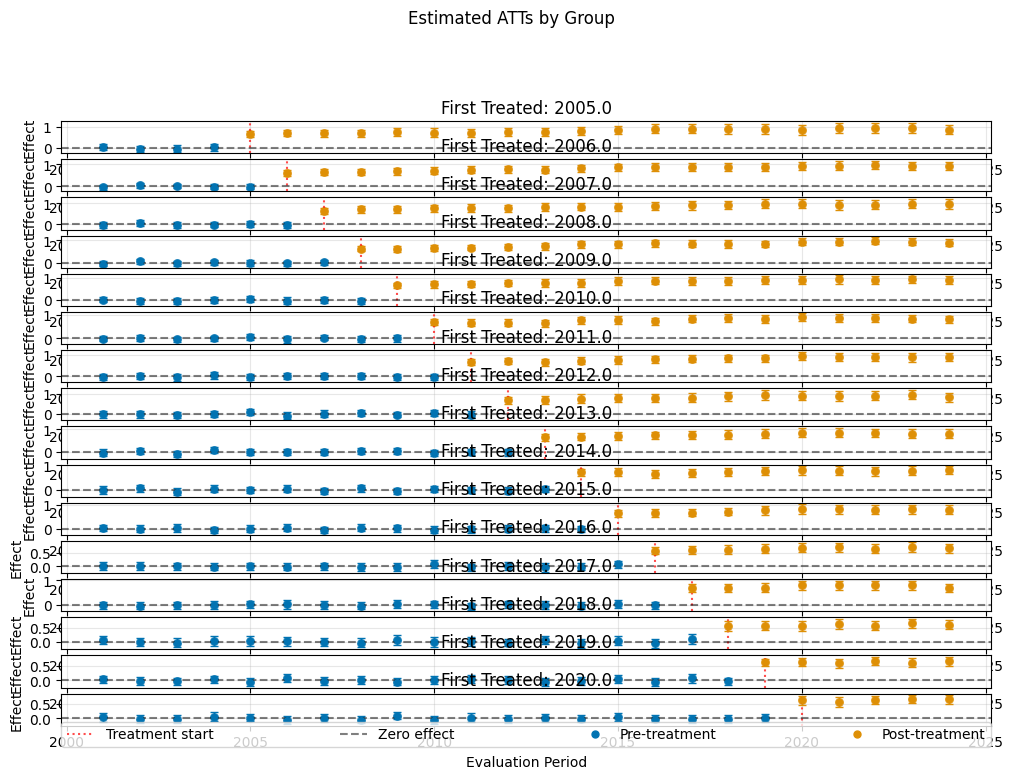

In [49]:
fig, ax = dml_obj_IE.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err         t  P>|t|    2.5 %   97.5 %
0.823158  0.01313 62.692732    0.0 0.797424 0.848892
------------------ Aggregated Effects         ------------------
           coef   std err          t     P>|t|     2.5 %    97.5 %
-19.0  0.031704  0.038345   0.826798  0.408352 -0.043451  0.106858
-18.0  0.009836  0.025370   0.387679  0.698254 -0.039889  0.059561
-17.0  0.000542  0.020964   0.025873  0.979359 -0.040546  0.041631
-16.0 -0.001583  0.019253  -0.082225  0.934468 -0.039318  0.036152
-15.0  0.002196  0.016180   0.135719  0.892043 -0.029516  0.033908
-14.0 -0.011883  0.014833  -0.801121  0.423062 -0.040955  0.017189
-13.0  0.012892  0.014398   0.895427  0.370559 -0.015327  0.041112
-12.0  0.000764  0.013037   0.058615  0.953259 -0.024789  0.026317
-11.0  0.001375  0.012558   0.109470  0.912830 -0.023239  0.025989

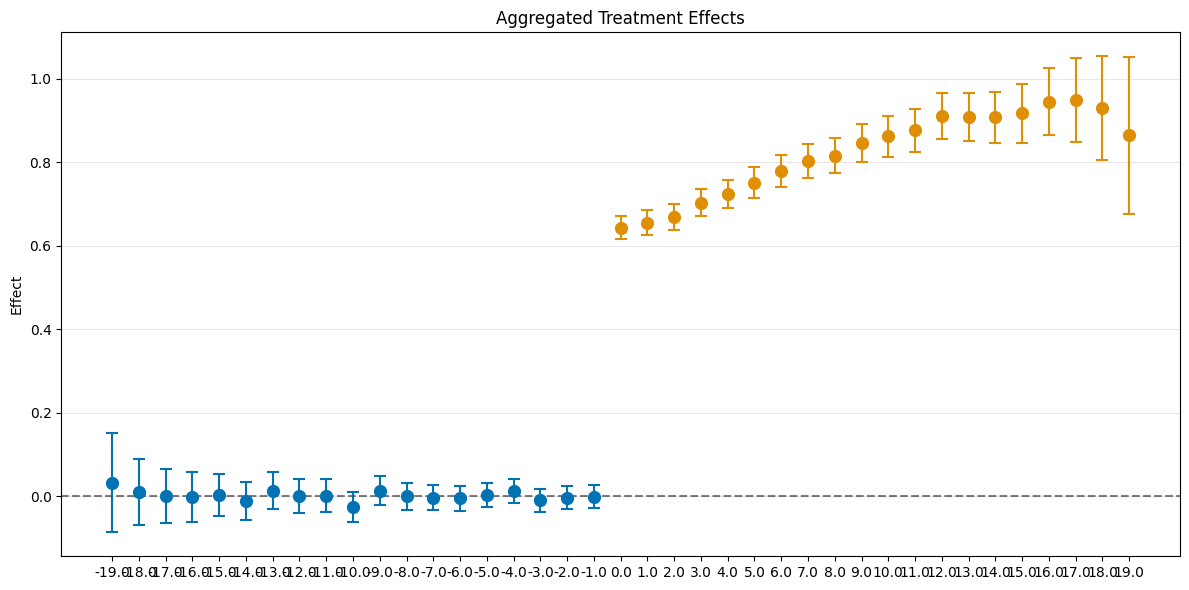

In [50]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_IE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_IE = dml_obj_IE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_IE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_IE)
fig, ax = aggregated_eventstudy_IE.plot_effects()

Com ML

In [56]:
dml_obj_IE_b = DoubleMLDIDMulti(
    obj_dml_data=dml_data_IE,
    ml_g=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    ml_m=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    control_group="never_treated",
    n_folds=10
)

dml_obj_IE_b.fit()
print(dml_obj_IE_b.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.0671   0.0406   1.6512  0.0987 -0.0125  0.1467
ATT(2005.0,2001,2002) -0.0621   0.0392  -1.5823  0.1136 -0.1390  0.0148
ATT(2005.0,2002,2003) -0.0110   0.0417  -0.2641  0.7917 -0.0927  0.0707
ATT(2005.0,2003,2004)  0.0322   0.0404   0.7985  0.4246 -0.0469  0.1114
ATT(2005.0,2004,2005)  0.6438   0.0407  15.8359  0.0000  0.5641  0.7235
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.6267   0.0388  16.1574  0.0000  0.5506  0.7027
ATT(2020.0,2019,2021)  0.5764   0.0442  13.0474  0.0000  0.4898  0.6630
ATT(2020.0,2019,2022)  0.6539   0.0410  15.9303  0.0000  0.5735  0.7344
ATT(2020.0,2019,2023)  0.6740   0.0382  17.6353  0.0000  0.5991  0.7489
ATT(2020.0,2019,2024)  0.6648   0.0390  17.0522  0.0000  0.5884  0.7412

[384 rows x 6 columns]


In [57]:
level = 0.95
ci = dml_obj_IE_b.confint(level=level)
dml_obj_IE_b.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_IE_b.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.086315  0.220475
ATT(2005.0,2001,2002) -0.210303  0.086096
ATT(2005.0,2002,2003) -0.168321  0.146312
ATT(2005.0,2003,2004) -0.120197  0.184666
ATT(2005.0,2004,2005)  0.490297  0.797307
...                         ...       ...
ATT(2020.0,2019,2020)  0.480218  0.773107
ATT(2020.0,2019,2021)  0.409608  0.743234
ATT(2020.0,2019,2022)  0.498918  0.808900
ATT(2020.0,2019,2023)  0.529684  0.818295
ATT(2020.0,2019,2024)  0.517572  0.811969

[384 rows x 2 columns]


================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err         t  P>|t|    2.5 %  97.5 %
0.821462  0.01328 61.856179    0.0 0.795433 0.84749
------------------ Aggregated Effects         ------------------
           coef   std err          t     P>|t|     2.5 %    97.5 %
-19.0  0.009197  0.039501   0.232819  0.815902 -0.068224  0.086618
-18.0  0.011067  0.026490   0.417800  0.676093 -0.040852  0.062987
-17.0  0.001592  0.021753   0.073205  0.941643 -0.041043  0.044228
-16.0 -0.005088  0.020181  -0.252124  0.800946 -0.044643  0.034467
-15.0  0.002156  0.016988   0.126908  0.899013 -0.031139  0.035451
-14.0 -0.011202  0.015484  -0.723466  0.469394 -0.041552  0.019147
-13.0  0.014337  0.014887   0.963029  0.335533 -0.014841  0.043515
-12.0 -0.001211  0.013534  -0.089476  0.928704 -0.027737  0.025315
-11.0  0.005270  0.013037   0.404241  0.686035 -0.020281  0.030821
-

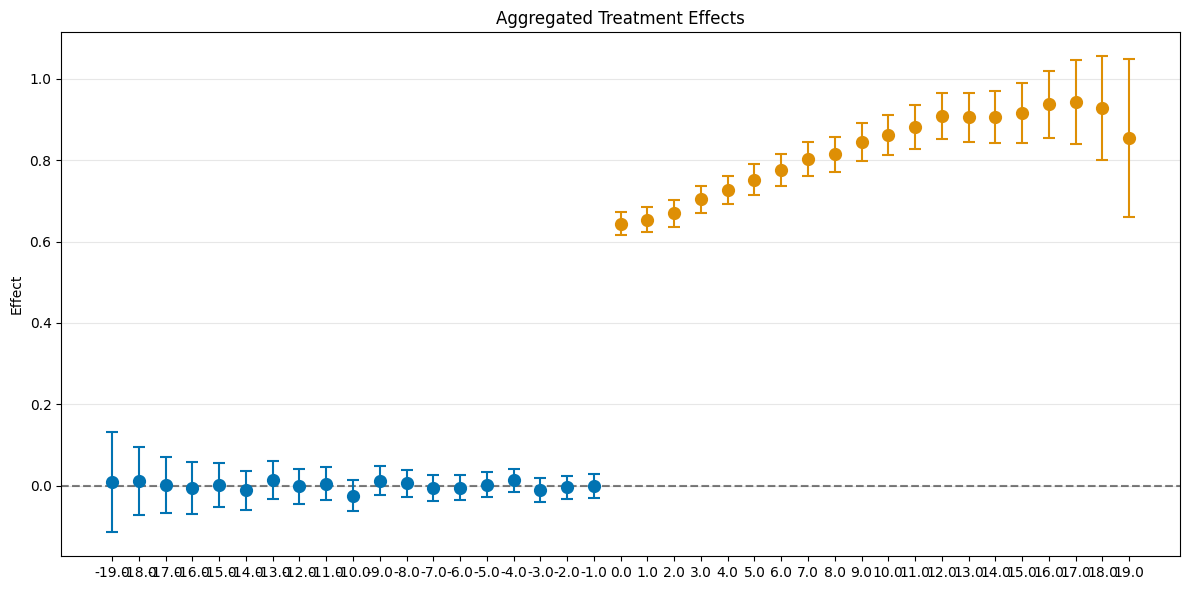

In [58]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_IE_b.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_IE_b = dml_obj_IE_b.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_IE_b.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_IE_b)
fig, ax = aggregated_eventstudy_IE_b.plot_effects()

### Análise de Sensibilidade 

* Utilizando a mesma função geradora dos dados, vamos variar gamma entre 0, 0.2, 0.4, 0.6, 0.8, 1.0 e 1.2.

In [316]:
df = panel.copy()

**Panel A - TWFE**

In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyfixest import feols

# 1. Função para atualizar Y e rodar TWFE
def testar_sensibilidade_twfe(df, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = df.copy()

        # Atualiza Y com novo gamma (efeito de spillover via WD1)
        panel['Y'] = (
            2 +
            0.6 * panel['X1'] +
            0.4 * panel['X2'] +
            0.2 * panel['X3'] +
            beta * panel['treatment_effect'] +
            gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
            panel['alpha_i'] +
            panel['lambda_t'] +
            panel['epsilon']
        )

        # Estimar TWFE
        model = feols("Y ~ D + X1 + X2 + X3 | year + codmun", data=panel)
        coef = model.coef()['D']
        se = model.se()['D']

        # IC 95%
        ci_lower = coef - 1.96 * se
        ci_upper = coef + 1.96 * se

        resultados.append({
            'gamma': gamma,
            'theta_hat': coef,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    return pd.DataFrame(resultados)


In [318]:
# 2. Rodar o teste de sensibilidade
df_resultados = testar_sensibilidade_twfe(df)

In [319]:
print(df_resultados.to_markdown())

|    |   gamma |   theta_hat |       se |   ci_lower |   ci_upper |
|---:|--------:|------------:|---------:|-----------:|-----------:|
|  0 |     0   |     3.58497 | 0.172545 |    3.24678 |    3.92316 |
|  1 |     0.4 |     3.42764 | 0.168039 |    3.09829 |    3.757   |
|  2 |     0.8 |     3.27032 | 0.163748 |    2.94937 |    3.59126 |
|  3 |     1.2 |     3.11299 | 0.159689 |    2.8     |    3.42598 |
|  4 |     1.6 |     2.95567 | 0.155879 |    2.65015 |    3.26119 |
|  5 |     2   |     2.79834 | 0.152337 |    2.49976 |    3.09693 |
|  6 |     2.4 |     2.64102 | 0.149083 |    2.34882 |    2.93322 |


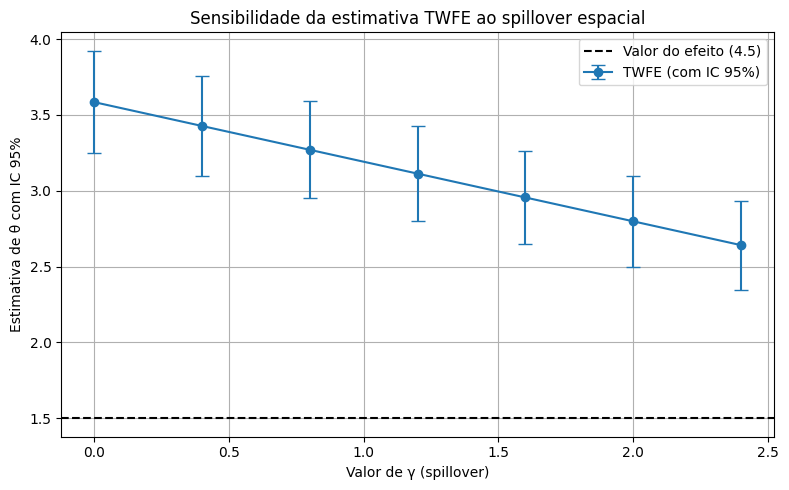

In [320]:
# 3 plotando os resultados
plt.figure(figsize=(8, 5))
plt.errorbar(df_resultados['gamma'], df_resultados['theta_hat'],
             yerr=1.96 * df_resultados['se'],
             fmt='o-', capsize=5, label='TWFE (com IC 95%)')

plt.axhline(1.5, color='black', linestyle='--', label='Valor do efeito (4.5)')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade da estimativa TWFE ao spillover espacial')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Panel B - Spatial DiD - Delgado e Florax (2015)**

In [321]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyfixest import feols

# Função para atualizar Y e rodar TWFE com WD1
def testar_sensibilidade_twfe_com_WD(df, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = df.copy()

        # Atualiza Y com efeito de spillover contínuo
        panel['Y'] = (
            2 +
            0.6 * panel['X1'] +
            0.4 * panel['X2'] +
            0.2 * panel['X3'] +
            beta * panel['treatment_effect'] +
            gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
            panel['alpha_i'] +
            panel['lambda_t'] +
            panel['epsilon']
        )

        # Estimar modelo com controle para WD
        model = feols("Y ~ D + WD_cumulativo + X1 + X2 + X3 | year + codmun", data=panel)
        coef = model.coef()['D']
        se = model.se()['D']

        # Intervalo de confiança
        ci_lower = coef - 1.96 * se
        ci_upper = coef + 1.96 * se

        resultados.append({
            'gamma': gamma,
            'theta_hat': coef,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    return pd.DataFrame(resultados)

In [322]:
# Rodar a simulação
df_dd_wd = testar_sensibilidade_twfe_com_WD(df)

In [323]:
print(df_dd_wd.to_markdown())

|    |   gamma |   theta_hat |       se |   ci_lower |   ci_upper |
|---:|--------:|------------:|---------:|-----------:|-----------:|
|  0 |     0   |     3.58461 | 0.172582 |    3.24635 |    3.92288 |
|  1 |     0.4 |     3.40717 | 0.167199 |    3.07946 |    3.73488 |
|  2 |     0.8 |     3.22973 | 0.162047 |    2.91212 |    3.54735 |
|  3 |     1.2 |     3.05229 | 0.15715  |    2.74428 |    3.36031 |
|  4 |     1.6 |     2.87485 | 0.152532 |    2.57589 |    3.17382 |
|  5 |     2   |     2.69742 | 0.148219 |    2.40691 |    2.98792 |
|  6 |     2.4 |     2.51998 | 0.144238 |    2.23727 |    2.80268 |


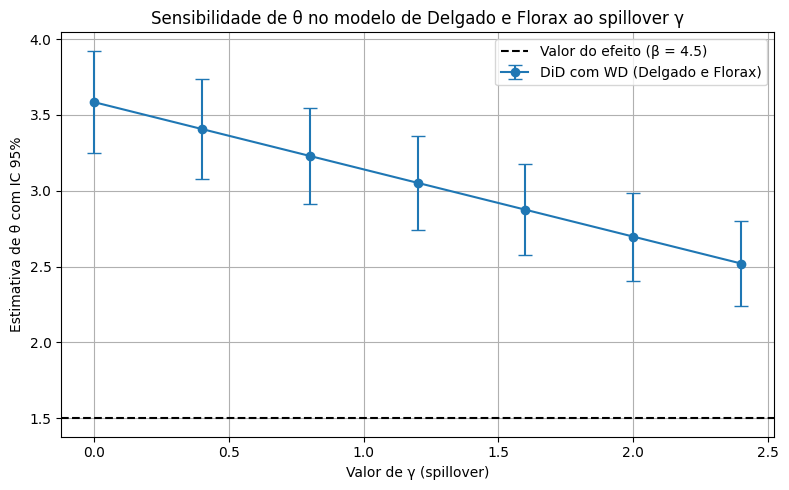

In [324]:
# Plotar os resultados
plt.figure(figsize=(8, 5))
plt.errorbar(df_dd_wd['gamma'], df_dd_wd['theta_hat'],
             yerr=1.96 * df_dd_wd['se'],
             fmt='o-', capsize=5, label='DiD com WD (Delgado e Florax)')

plt.axhline(1.5, color='black', linestyle='--', label='Valor do efeito (β = 4.5)')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade de θ no modelo de Delgado e Florax ao spillover γ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Aqui temos o viés do spillover espacial controlado. Logo o viés do tratamento deve-se ao tratamento escalonado e ao grupo de comparação desbalanciado (falha do SUTVA)

* (a) Viés de comparação entre grupos desbalanceados (problema de pesos negativos ou implícitos) / Comparações inválidas entre grupos tratados
  * O TWFE tradicional compara unidades tratadas com outras já tratadas há mais tempo, não apenas com não tratadas.
  * Isso gera comparações inválidas, que não estimam o ATT de forma correta.
  * Como consequência, mesmo sem spillover, a estimativa de D não reflete fielmente o efeito médio do tratamento.

* (b) Violação do SUTVA por natureza do tratamento escalonado / Violação do SUTVA pelo escalonamento
  * O SUTVA (Stable Unit Treatment Value Assumption) pressupõe que o efeito do tratamento sobre uma unidade não depende de quando nem de quem mais foi tratado.
  * Em modelos com tratamento escalonado, essa suposição frequentemente falha.
  * Por exemplo, um município tratado em 2010 pode estar afetando outros já ou ainda não tratados, mesmo após controlar por spillover espacial direto.



**Panel C - Gardner (2022)**

Did2s aplica uma abordagem em duas etapas, que permite estimar o efeito médio do tratamento (ATT) de forma válida sob adoção escalonada. No entanto, Did2s ainda assume SUTVA (Stable Unit Treatment Value Assumption).

In [325]:
from pyfixest.did import did2s
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pyfixest.did import did2s
import pandas as pd
import numpy as np

def testar_sensibilidade_gardner(df, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = df.copy()

        # Atualiza Y com efeito de spillover (gamma * WD)
        panel['Y'] = (
            2 +
            0.6 * panel['X1'] +
            0.4 * panel['X2'] +
            0.2 * panel['X3'] +
            beta * panel['treatment_effect'] +
            gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
            panel['alpha_i'] +
            panel['lambda_t'] +
            panel['epsilon']
        )

        try:
            fit = did2s(
                data=panel,
                yname="Y",
                treatment="D",
                first_stage="~ X1 + X2 + X3 | codmun + year",
                second_stage="~ D",
                cluster="codmun"
            )

            coef = fit.coef()['D']
            se = fit.se()['D']
            ci_lower = coef - 1.96 * se
            ci_upper = coef + 1.96 * se

            resultados.append({
                'gamma': gamma,
                'theta_hat': coef,
                'se': se,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper
            })

        except Exception as e:
            print(f"Erro em γ={gamma}: {e}")
            resultados.append({
                'gamma': gamma,
                'theta_hat': np.nan,
                'se': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan
            })

    return pd.DataFrame(resultados)

In [326]:
df_gardner = testar_sensibilidade_gardner(df)

Erro em γ=0.4: Unable to allocate 5.81 GiB for an array with shape (139325, 5600) and data type float64


KeyboardInterrupt: 

In [278]:
print(df_gardner.to_markdown())

|    |   gamma |   theta_hat |        se |   ci_lower |   ci_upper |
|---:|--------:|------------:|----------:|-----------:|-----------:|
|  0 |     0   |     3.7589  | 0.0136143 |    3.73222 |    3.78559 |
|  1 |     0.4 |     3.60836 | 0.0147652 |    3.57942 |    3.63729 |
|  2 |     0.8 |     3.45781 | 0.0165159 |    3.42544 |    3.49018 |
|  3 |     1.2 |     3.30726 | 0.0186987 |    3.27061 |    3.34391 |
|  4 |     1.6 |     3.15671 | 0.0211805 |    3.1152  |    3.19823 |
|  5 |     2   |     3.00617 | 0.0238681 |    2.95939 |    3.05295 |
|  6 |     2.4 |     2.85562 | 0.0266996 |    2.80329 |    2.90795 |


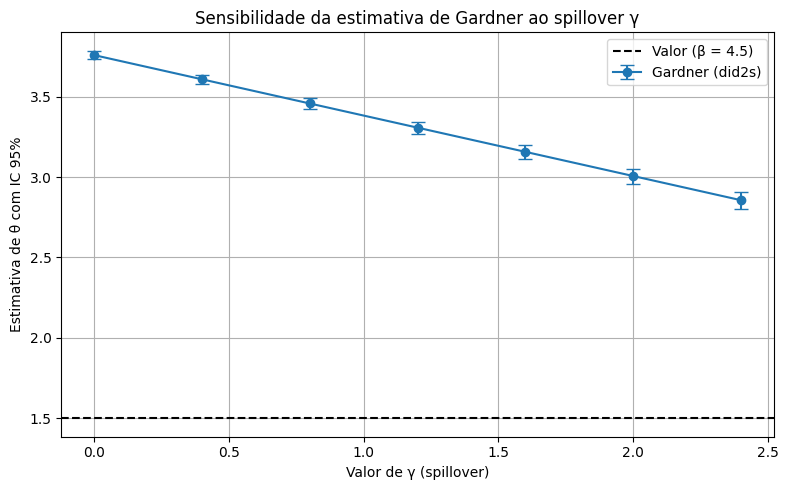

In [279]:
plt.figure(figsize=(8, 5))
plt.errorbar(df_gardner['gamma'], df_gardner['theta_hat'],
             yerr=1.96 * df_gardner['se'],
             fmt='o-', capsize=5, label='Gardner (did2s)')

plt.axhline(1.5, color='black', linestyle='--', label='Valor (β = 4.5)')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade da estimativa de Gardner ao spillover γ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Panel C - Callaway & SantAnna**

In [ ]:
def testar_sensibilidade_callaway_santanna(df, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = df.copy()
        panel['Y'] = (
            2 +
            0.6 * panel['X1'] +
            0.4 * panel['X2'] +
            0.2 * panel['X3'] +
            beta * panel['treatment_effect'] +
            gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
            panel['alpha_i'] +
            panel['lambda_t'] +
            panel['epsilon']
        )

        # Ajusta a variável de tratamento (g_treated)
        panel['g_treated'] = panel['g_treated'].replace(0, np.inf)
        panel['g_treated'] = panel['g_treated'].astype(float).fillna(np.inf)

        # Garante tipo e ordenação
        panel['year'] = panel['year'].astype(int)
        panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

        try:
            # Criação do objeto DoubleMLPanelData
            dml_data = DoubleMLPanelData(
                data=panel,
                y_col="Y",
                d_cols="g_treated",
                id_col="codmun",
                t_col="year",
                x_cols=['X1', 'X2', 'X3']
            )

            # Estimador com regressões lineares
            dml_obj = DoubleMLDIDMulti(
                obj_dml_data=dml_data,
                ml_g=LinearRegression(),
                ml_m=LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000),
                control_group="never_treated",
                n_folds=5  # Pode reduzir para acelerar
            )

            dml_obj.fit()
            dml_obj.bootstrap(n_rep_boot=500)

            # Agregação dos efeitos
            aggregated = dml_obj.aggregate("eventstudy")
            overall = aggregated.overall_summary.iloc[0]

            resultados.append({
                'gamma': gamma,
                'theta_hat': overall["coef"],
                'se': overall["std err"],
                'ci_lower': overall["2.5 %"],
                'ci_upper': overall["97.5 %"]
            })

        except Exception as e:
            print(f"Erro em gamma = {gamma}: {e}")
            resultados.append({
                'gamma': gamma,
                'theta_hat': np.nan,
                'se': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan
            })

    return pd.DataFrame(resultados)

In [281]:
df_csa = testar_sensibilidade_callaway_santanna(df)

In [282]:
print(df_csa.to_markdown())

|    |   gamma |   theta_hat |        se |   ci_lower |   ci_upper |
|---:|--------:|------------:|----------:|-----------:|-----------:|
|  0 |     0   |     4.05825 | 0.0172771 |    4.02439 |    4.09212 |
|  1 |     0.4 |     3.89364 | 0.018213  |    3.85794 |    3.92933 |
|  2 |     0.8 |     3.72906 | 0.0208124 |    3.68827 |    3.76985 |
|  3 |     1.2 |     3.5648  | 0.0246159 |    3.51655 |    3.61305 |
|  4 |     1.6 |     3.40027 | 0.0290923 |    3.34325 |    3.45729 |
|  5 |     2   |     3.23625 | 0.0339366 |    3.16974 |    3.30276 |
|  6 |     2.4 |     3.07178 | 0.0391516 |    2.99504 |    3.14851 |


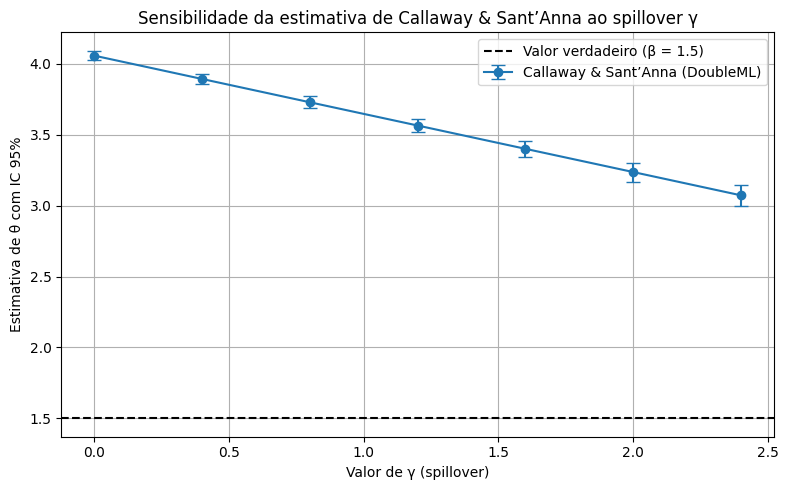

In [283]:
plt.figure(figsize=(8, 5))
plt.errorbar(df_csa['gamma'], df_csa['theta_hat'],
             yerr=1.96 * df_csa['se'],
             fmt='o-', capsize=5, label='Callaway & Sant’Anna (DoubleML)')

plt.axhline(1.5, color='black', linestyle='--', label='Valor verdadeiro (β = 1.5)')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade da estimativa de Callaway & Sant’Anna ao spillover γ')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Panel D - Spatial Double Robust DiD**

* Direct Effect Estimation

In [ ]:
# 1. Painel para efeitos diretos (tratados vs never treated limpos)
panel_de = panel[
    (panel['treated'] == 1) |  # tratados diretos
    ((panel['never_treated'] == 1) & (panel['WD_cumulativo'] == 0))  # nunca tratados limpos (sem spillover)
].copy()

# 2. Painel para efeitos indiretos (vizinhos dos tratados vs never treated limpos)
panel_id = panel[
    ((panel['neighbor_of_treated'] == 1) & (panel['treated'] == 0)) |  # vizinhos não tratados diretamente
    ((panel['never_treated'] == 1) & (panel['WD_cumulativo'] == 0))    # nunca tratados limpos (sem spillover)
].copy()


In [291]:
panel_de.loc[panel_de['g_treated'] == 0, 'g_treated'] = np.inf
panel_de['g_treated'] = panel_de['g_treated'].astype(float)
panel_de['year'] = panel_de['year'].astype(int)
panel_de['g_treated'] = panel_de['g_treated'].fillna(np.inf)
panel_de = panel_de.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [292]:
def testar_sensibilidade_spatial_dml_direct(panel_de, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = panel_de.copy()
        # Atualiza Y com efeito direto de spillover binário (WD1)
        panel['Y'] = (
            2 +
            0.6 * panel['X1'] +
            0.4 * panel['X2'] +
            0.2 * panel['X3'] +
            beta * panel['treatment_effect'] +
            gamma * panel['WD_cumulativo'] * (1 - panel['D']) +
            panel['alpha_i'] +
            panel['lambda_t'] +
            panel['epsilon']
        )

        # Preparação para DoubleML
        panel['g_treated'] = panel['g_treated'].replace(0, np.inf)
        panel['g_treated'] = panel['g_treated'].astype(float).fillna(np.inf)
        panel['year'] = panel['year'].astype(int)
        panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

        # Dados para o estimador DoubleML
        dml_data = DoubleMLPanelData(
            data=panel,
            y_col="Y",
            d_cols="g_treated",
            id_col="codmun",
            t_col="year",
            x_cols=['X1', 'X2', 'X3']
        )

        dml_obj = DoubleMLDIDMulti(
            obj_dml_data=dml_data,
            ml_g=LinearRegression(),
            ml_m=LogisticRegression(penalty=None),
            control_group="never_treated",
            n_folds=10
        )

        # Estima e aplica bootstrap
        dml_obj.fit()
        dml_obj.bootstrap(n_rep_boot=500)

        # Agrega os efeitos estimados
        aggregated = dml_obj.aggregate("eventstudy")
        overall = aggregated.overall_summary.iloc[0]

        resultados.append({
            'gamma': gamma,
            'theta_hat': overall["coef"],
            'se': overall["std err"],
            'ci_lower': overall["2.5 %"],
            'ci_upper': overall["97.5 %"]
        })

    return pd.DataFrame(resultados)

In [293]:
df_direct = testar_sensibilidade_spatial_dml_direct(panel_de)

In [294]:
print(df_direct.to_markdown())

|    |   gamma |   theta_hat |        se |   ci_lower |   ci_upper |
|---:|--------:|------------:|----------:|-----------:|-----------:|
|  0 |     0   |     4.057   | 0.0174675 |    4.02276 |    4.09123 |
|  1 |     0.4 |     3.99051 | 0.0182835 |    3.95467 |    4.02634 |
|  2 |     0.8 |     3.92397 | 0.0205707 |    3.88366 |    3.96429 |
|  3 |     1.2 |     3.85776 | 0.0239371 |    3.81085 |    3.90468 |
|  4 |     1.6 |     3.79128 | 0.0279894 |    3.73642 |    3.84614 |
|  5 |     2   |     3.7247  | 0.0324535 |    3.66109 |    3.7883  |
|  6 |     2.4 |     3.65836 | 0.0371914 |    3.58547 |    3.73126 |


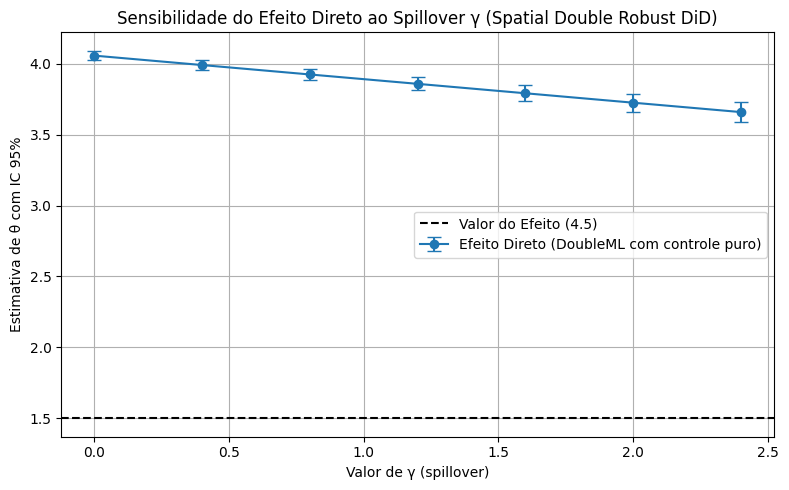

In [295]:
plt.figure(figsize=(8, 5))
plt.errorbar(df_direct['gamma'], df_direct['theta_hat'],
             yerr=1.96 * df_direct['se'],
             fmt='o-', capsize=5, label='Efeito Direto (DoubleML com controle puro)')

plt.axhline(1.5, color='black', linestyle='--', label='Valor do Efeito (4.5)')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade do Efeito Direto ao Spillover γ (Spatial Double Robust DiD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


* Indirect Effect Estimation

In [226]:
panel_id.loc[panel_id['g_neighbor'] == 0, 'g_neighbor'] = np.inf
panel_id['g_neighbor'] = panel_id['g_neighbor'].astype(float)
panel_id['year'] = panel_id['year'].astype(int)
panel_id['g_neighbor'] = panel_id['g_neighbor'].fillna(np.inf)
panel_id = panel_id.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [229]:
def testar_sensibilidade_spatial_dml_indirect(panel_id, beta=1.5, gammas=[0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4]):
    resultados = []

    for gamma in gammas:
        panel = panel_id.copy()

        # Atualiza Y com o novo valor de spillover
        panel['Y'] = (
            2
            + 0.6 * panel['X1']
            + 0.4 * panel['X2']
            + 0.2 * panel['X3']
            + beta * panel['treatment_effect']
            + gamma * panel['WD1']  
            + panel['alpha_i']
            + panel['lambda_t']
            + panel['epsilon']
        )

        # Ajuste da variável de grupo de vizinhos tratados (g_neighbor)
        panel['g_neighbor'] = panel['g_neighbor'].replace(0, np.inf)
        panel['g_neighbor'] = panel['g_neighbor'].astype(float).fillna(np.inf)

        # Conversão do ano para inteiro e ordenação
        panel['year'] = panel['year'].astype(int)
        panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

        # Define os dados em painel para o estimador
        dml_data = DoubleMLPanelData(
            data=panel,
            y_col="Y",
            d_cols="g_neighbor",
            id_col="codmun",
            t_col="year",
            x_cols=['X1', 'X2', 'X3']
        )

        # Estimador DoubleML
        dml_obj = DoubleMLDIDMulti(
            obj_dml_data=dml_data,
            ml_g=LinearRegression(),
            ml_m=LogisticRegression(penalty=None, solver='lbfgs'),
            control_group="never_treated",
            n_folds=10
        )

        # Ajuste e inferência via bootstrap
        dml_obj.fit()
        dml_obj.bootstrap(n_rep_boot=500)

        # Agrega os efeitos
        aggregated = dml_obj.aggregate("eventstudy")
        overall = aggregated.overall_summary.iloc[0]  # primeira linha: efeito médio

        resultados.append({
            'gamma': gamma,
            'theta_hat': overall["coef"],
            'se': overall["std err"],
            'ci_lower': overall["2.5 %"],
            'ci_upper': overall["97.5 %"]
        })

    return pd.DataFrame(resultados)

In [230]:
df_indirect = testar_sensibilidade_spatial_dml_indirect(panel_id)

In [ ]:
plt.figure(figsize=(8, 5))
plt.errorbar(df_indirect['gamma'], df_indirect['theta_hat'],
             yerr=1.96 * df_indirect['se'],
             fmt='s--', capsize=5, color='tab:orange',
             label='Efeito Indireto (DoubleML com controle puro)')

plt.axhline(0, color='black', linestyle='--', label='Referência: Efeito indireto nulo sob H₀')
plt.xlabel('Valor de γ (spillover)')
plt.ylabel('Estimativa de θ com IC 95%')
plt.title('Sensibilidade do Efeito Indireto ao Spillover γ (Spatial Double Robust DiD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Panel E - Spatial DML DiD**

* Direct Effect Estimation

* Indirect Effect Estimation